# Polymer New Data End-to-End

This notebook is the single self-contained workflow for the new polymer data upload. It inventories the uploaded context, ingests the spreadsheets, harmonizes them into one canonical long-form dataset, runs explicit QC, builds leakage-safe grouped splits, trains teacher-free baselines, runs PCA diagnostics, and exports reproducible artifacts.

**Explicit limits**

- Everything lives in this notebook on purpose. There is no `src/` package, helper module tree, or multi-notebook split for this phase.
- This is deliberately teacher-free. There is no MMA solution surrogate reuse, no Jacobian matching, and no attempt to fake a full PCINN recreation on mechanism-mismatched data.
- Regime labels for the uploaded figure extracts are conservative file-identity inferences, not claims that the workbook itself contains full mechanistic provenance.


## Section 2 - Setup: install packages, import libraries, configure environment

All package installation statements and all imports are intentionally consolidated into the single first code cell below. No later cell repeats install or import boilerplate.


In [1]:
from __future__ import annotations

import importlib
import json
import math
import os
import random
import re
import subprocess
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Callable, Mapping, Sequence

NOTEBOOK_BOOTSTRAP_ROOT = Path.cwd().resolve()
os.environ.setdefault("HOME", str(NOTEBOOK_BOOTSTRAP_ROOT))
os.environ.setdefault("USERPROFILE", str(NOTEBOOK_BOOTSTRAP_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str((NOTEBOOK_BOOTSTRAP_ROOT / ".mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

PACKAGE_IMPORT_NAMES: dict[str, str] = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "scikit-learn": "sklearn",
    "openpyxl": "openpyxl",
    "ipython": "IPython",
}
UPGRADE_PACKAGES = False


def ensure_python_packages(package_import_names: Mapping[str, str], upgrade: bool = False) -> None:
    """Install missing packages, and optionally upgrade all packages, in the active interpreter."""

    missing_packages: list[str] = []
    if not upgrade:
        for package_name, import_name in package_import_names.items():
            try:
                importlib.import_module(import_name)
            except Exception:
                missing_packages.append(package_name)

    packages_to_install = list(package_import_names.keys()) if upgrade else missing_packages
    if not packages_to_install:
        return

    install_command = [sys.executable, "-m", "pip", "install", "--quiet"]
    if upgrade:
        install_command.append("--upgrade")
    install_command.extend(packages_to_install)
    print(f"Installing packages: {packages_to_install}")
    completed = subprocess.run(
        install_command,
        check=False,
        capture_output=True,
        text=True,
    )
    if completed.returncode != 0:
        raise RuntimeError(
            "Package installation failed.\n"
            f"Command: {' '.join(install_command)}\n"
            f"stdout:\n{completed.stdout}\n"
            f"stderr:\n{completed.stderr}"
        )


ensure_python_packages(PACKAGE_IMPORT_NAMES, upgrade=UPGRADE_PACKAGES)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
import scipy
import sklearn
from IPython import get_ipython
from IPython.display import Markdown, display
from sklearn.base import RegressorMixin
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

version_report = pd.DataFrame(
    [
        ("python", sys.version.split()[0]),
        ("numpy", np.__version__),
        ("pandas", pd.__version__),
        ("matplotlib", matplotlib.__version__),
        ("scipy", scipy.__version__),
        ("scikit-learn", sklearn.__version__),
        ("openpyxl", openpyxl.__version__),
    ],
    columns=["package", "version"],
)
display(version_report)
print(f"Notebook seed: {SEED}")


,package,version
0,python,3.13.5
1,numpy,2.3.5
2,pandas,2.2.3
3,matplotlib,3.10.8
4,scipy,1.17.0
5,scikit-learn,1.8.0
6,openpyxl,3.1.5


Notebook seed: 42


## Section 3 - File Inventory and Path Verification

The notebook fails early on missing critical data files. Context files are inventoried as well, but only the new spreadsheet inputs are treated as hard blockers.


In [2]:
project_root_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(
    (
        candidate
        for candidate in project_root_candidates
        if (candidate / "README.md").exists() and (candidate / "MMA_PCINN.ipynb").exists()
    ),
    Path.cwd().resolve(),
)

expected_context_files = [
    "MMA_PCINN.ipynb",
    "Original PCINN Paper.pdf",
    "PCA_Exploration.ipynb",
]
expected_data_files = [
    "MMA_fig1a.xlsx",
    "MMA_fig2a.xlsx",
    "MMA_fig2b_Mn.xlsx",
    "MMA_fig2b_PDI.xlsx",
    "STY_fig1b.xlsx",
    "STY_fig2c.xlsx",
    "STY_fig2d_Mn.xlsx",
    "STY_fig2d_PDI.xlsx",
    "PSBMA NMR.xlsx",
]

inventory_rows: list[dict[str, object]] = []
for category, expected_names in (("context", expected_context_files), ("data", expected_data_files)):
    for expected_name in expected_names:
        matches = sorted(PROJECT_ROOT.rglob(expected_name))
        inventory_rows.append(
            {
                "category": category,
                "expected_name": expected_name,
                "match_count": len(matches),
                "exists": len(matches) > 0,
                "resolved_path": str(matches[0].relative_to(PROJECT_ROOT)) if matches else "",
            }
        )

inventory_df = pd.DataFrame(inventory_rows).sort_values(["category", "expected_name"]).reset_index(drop=True)
display(inventory_df)

missing_data_files = inventory_df.loc[(inventory_df["category"] == "data") & (~inventory_df["exists"]), "expected_name"].tolist()
if missing_data_files:
    raise FileNotFoundError(f"Critical spreadsheet files are missing: {missing_data_files}")

unresolved_context_files = inventory_df.loc[(inventory_df["category"] == "context") & (~inventory_df["exists"]), "expected_name"].tolist()
if unresolved_context_files:
    print(f"Context files missing but not fatal: {unresolved_context_files}")

RESOLVED_FILE_LOOKUP = {
    row.expected_name: PROJECT_ROOT / row.resolved_path
    for row in inventory_df.itertuples(index=False)
    if row.exists
}
print(f"Resolved project root: {PROJECT_ROOT}")


,category,expected_name,match_count,exists,resolved_path
0,context,MMA_PCINN.ipynb,1,True,MMA_PCINN.ipynb
1,context,Original PCINN Paper.pdf,1,True,Original PCINN Paper.pdf
2,context,PCA_Exploration.ipynb,1,True,PCA_Exploration.ipynb
3,data,MMA_fig1a.xlsx,1,True,MMA_fig1a.xlsx
4,data,MMA_fig2a.xlsx,1,True,MMA_fig2a.xlsx
5,data,MMA_fig2b_Mn.xlsx,1,True,MMA_fig2b_Mn.xlsx
6,data,MMA_fig2b_PDI.xlsx,1,True,MMA_fig2b_PDI.xlsx
7,data,PSBMA NMR.xlsx,1,True,PSBMA NMR.xlsx
8,data,STY_fig1b.xlsx,1,True,STY_fig1b.xlsx
9,data,STY_fig2c.xlsx,1,True,STY_fig2c.xlsx


Resolved project root: /mnt/data


## Section 4 - Configuration Block

All notebook-wide paths, schema expectations, metadata assumptions, subset labels, split parameters, and model hyperparameters are declared once here.


In [3]:
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "polymer_new_data_end_to_end"
FIGURE_DIR = ARTIFACT_ROOT / "figures"
for output_path in (ARTIFACT_ROOT, FIGURE_DIR):
    output_path.mkdir(parents=True, exist_ok=True)

CANONICAL_COLUMNS = [
    "row_id", "source_file", "source_sheet", "paper_id", "curve_id", "condition_id", "regime_family", "subset_name",
    "monomer", "temperature_C", "time_value_raw", "time_unit_raw", "time_min", "residence_time_min", "solvent",
    "initiator", "cta", "reactor_type", "atmosphere", "pressure_bar", "light_wavelength_nm", "light_intensity_mw_cm2",
    "measurement_type", "target_raw", "target_raw_unit", "conversion_fraction", "conversion_percent",
    "neg_log_one_minus_conversion", "Mn", "PDI", "Mw_derived", "target_value_final", "target_name_final",
    "digitized_from_figure", "notes", "ingestion_warning", "validation_status", "is_duplicate_suspected",
    "is_out_of_range", "source_group", "layout_family", "time_basis", "model_time_min", "temperature_time_interaction",
    "log10_Mn", "log_PDI", "nmr_monomer_integral", "nmr_polymer_integral",
]

FILE_SPECS: list[dict[str, object]] = [
    {"expected_name": "MMA_fig1a.xlsx", "source_group": "MMA_fig1a", "sheet_name": "MMA", "layout_family": "paired_time_series", "paper_id": "digitized_mma_sty_upload", "monomer": "MMA", "regime_family": "raft_photo_flow_mma", "subset_name": "primary_mma_flow_conversion", "measurement_type": "conversion_kinetics", "time_basis": "residence_time", "time_unit_raw": "min", "target_raw_unit": "neg_log_one_minus_conversion", "reactor_type": "flow", "digitized_from_figure": True, "notes": "Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axis label."},
    {"expected_name": "MMA_fig2a.xlsx", "source_group": "MMA_fig2a", "sheet_name": "MMA_fig2a", "layout_family": "paired_time_series", "paper_id": "digitized_mma_sty_upload", "monomer": "MMA", "regime_family": "raft_bulk_mma", "subset_name": "exploratory_mma_time_conversion", "measurement_type": "conversion_kinetics", "time_basis": "elapsed_time", "time_unit_raw": "min", "target_raw_unit": "neg_log_one_minus_conversion", "reactor_type": "batch_assumed", "digitized_from_figure": True, "notes": "Elapsed-time conversion curves digitized from a figure. Regime label is inferred from file family rather than encoded workbook metadata."},
    {"expected_name": "MMA_fig2b_Mn.xlsx", "source_group": "MMA_fig2b", "sheet_name": "MMA_fig2b_Mn", "layout_family": "paired_conversion_response", "paper_id": "digitized_mma_sty_upload", "monomer": "MMA", "regime_family": "raft_bulk_mma", "subset_name": "exploratory_mma_molecular_weight", "measurement_type": "Mn", "time_basis": "conversion_axis", "time_unit_raw": "", "target_raw_unit": "g_per_mol_assumed", "reactor_type": "batch_assumed", "digitized_from_figure": True, "notes": "Mn versus conversion data digitized from a figure. Molecular-weight unit is assumed to be g/mol because the workbook does not state units explicitly."},
    {"expected_name": "MMA_fig2b_PDI.xlsx", "source_group": "MMA_fig2b", "sheet_name": "MMA_fig2b_PDI", "layout_family": "paired_conversion_response", "paper_id": "digitized_mma_sty_upload", "monomer": "MMA", "regime_family": "raft_bulk_mma", "subset_name": "exploratory_mma_molecular_weight", "measurement_type": "PDI", "time_basis": "conversion_axis", "time_unit_raw": "", "target_raw_unit": "dimensionless", "reactor_type": "batch_assumed", "digitized_from_figure": True, "notes": "PDI versus conversion data digitized from a figure. Regime metadata is inferred conservatively from the shared figure family."},
    {"expected_name": "STY_fig1b.xlsx", "source_group": "STY_fig1b", "sheet_name": "STY", "layout_family": "paired_time_series", "paper_id": "digitized_mma_sty_upload", "monomer": "STY", "regime_family": "raft_photo_flow_sty", "subset_name": "secondary_sty_flow_conversion", "measurement_type": "conversion_kinetics", "time_basis": "residence_time", "time_unit_raw": "min", "target_raw_unit": "neg_log_one_minus_conversion", "reactor_type": "flow", "digitized_from_figure": True, "notes": "Residence-time conversion curves digitized from a styrene flow figure."},
    {"expected_name": "STY_fig2c.xlsx", "source_group": "STY_fig2c", "sheet_name": "STY_fig2c", "layout_family": "paired_time_series", "paper_id": "digitized_mma_sty_upload", "monomer": "STY", "regime_family": "raft_bulk_sty", "subset_name": "exploratory_sty_time_conversion", "measurement_type": "conversion_kinetics", "time_basis": "elapsed_time", "time_unit_raw": "h", "target_raw_unit": "neg_log_one_minus_conversion", "reactor_type": "batch_assumed", "digitized_from_figure": True, "notes": "Elapsed-time conversion curves digitized from a figure. Time is reported in hours in the workbook."},
    {"expected_name": "STY_fig2d_Mn.xlsx", "source_group": "STY_fig2d", "sheet_name": "STY_fig2d_Mn", "layout_family": "paired_conversion_response", "paper_id": "digitized_mma_sty_upload", "monomer": "STY", "regime_family": "raft_bulk_sty", "subset_name": "exploratory_sty_molecular_weight", "measurement_type": "Mn", "time_basis": "conversion_axis", "time_unit_raw": "", "target_raw_unit": "g_per_mol_assumed", "reactor_type": "batch_assumed", "digitized_from_figure": True, "notes": "Mn versus conversion data digitized from a figure. The batch-style regime assignment is an inference, not explicit workbook metadata."},
    {"expected_name": "STY_fig2d_PDI.xlsx", "source_group": "STY_fig2d", "sheet_name": "STY_fig2d_PDI", "layout_family": "paired_conversion_response", "paper_id": "digitized_mma_sty_upload", "monomer": "STY", "regime_family": "raft_bulk_sty", "subset_name": "exploratory_sty_molecular_weight", "measurement_type": "PDI", "time_basis": "conversion_axis", "time_unit_raw": "", "target_raw_unit": "dimensionless", "reactor_type": "batch_assumed", "digitized_from_figure": True, "notes": "PDI versus conversion data digitized from a figure. The regime assignment is conservative and file-driven."},
    {"expected_name": "PSBMA NMR.xlsx", "source_group": "PSBMA_NMR", "sheet_name": "Sheet1", "layout_family": "nmr_offset_table", "paper_id": "psbma_nmr_upload", "monomer": "PSBMA", "regime_family": "conversion_only_other", "subset_name": "exploratory_psbma_nmr", "measurement_type": "nmr_conversion", "time_basis": "elapsed_time", "time_unit_raw": "min", "target_raw_unit": "conversion_percent", "reactor_type": "unknown", "digitized_from_figure": False, "notes": "Offset-header NMR worksheet provided directly as a spreadsheet rather than a digitized plot."},
]

for file_spec in FILE_SPECS:
    file_spec["file_path"] = RESOLVED_FILE_LOOKUP[file_spec["expected_name"]]

MODELING_SUBSET_NAMES = ["primary_mma_flow_conversion", "secondary_sty_flow_conversion"]
MODELING_TARGET_COLUMN = "neg_log_one_minus_conversion"
MODELING_FEATURE_COLUMNS = ["temperature_C", "model_time_min", "temperature_time_interaction"]
GROUP_COLUMN = "curve_id"
GROUP_SPLIT_FOLDS = 4
MINIMUM_GROUPS_FOR_MODELING = 3
CONVERSION_TOLERANCE = 1e-6
PAIRING_TOLERANCE = 0.03
FIGURE_DPI = 150

BASELINE_MODEL_FACTORIES: dict[str, Callable[[], RegressorMixin | Pipeline]] = {
    "random_forest": lambda: RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=2, random_state=SEED),
    "small_mlp": lambda: Pipeline(steps=[("scale", StandardScaler()), ("model", MLPRegressor(hidden_layer_sizes=(32, 16), activation="relu", alpha=1e-3, learning_rate_init=1e-3, max_iter=4000, random_state=SEED))]),
}

configuration_preview = pd.DataFrame([
    {"expected_name": file_spec["expected_name"], "source_group": file_spec["source_group"], "layout_family": file_spec["layout_family"], "regime_family": file_spec["regime_family"], "subset_name": file_spec["subset_name"], "measurement_type": file_spec["measurement_type"]}
    for file_spec in FILE_SPECS
])
display(configuration_preview)
print(f"Artifact root: {ARTIFACT_ROOT}")


,expected_name,source_group,layout_family,regime_family,subset_name,measurement_type
0,MMA_fig1a.xlsx,MMA_fig1a,paired_time_series,raft_photo_flow_mma,primary_mma_flow_conversion,conversion_kinetics
1,MMA_fig2a.xlsx,MMA_fig2a,paired_time_series,raft_bulk_mma,exploratory_mma_time_conversion,conversion_kinetics
2,MMA_fig2b_Mn.xlsx,MMA_fig2b,paired_conversion_response,raft_bulk_mma,exploratory_mma_molecular_weight,Mn
3,MMA_fig2b_PDI.xlsx,MMA_fig2b,paired_conversion_response,raft_bulk_mma,exploratory_mma_molecular_weight,PDI
4,STY_fig1b.xlsx,STY_fig1b,paired_time_series,raft_photo_flow_sty,secondary_sty_flow_conversion,conversion_kinetics
5,STY_fig2c.xlsx,STY_fig2c,paired_time_series,raft_bulk_sty,exploratory_sty_time_conversion,conversion_kinetics
6,STY_fig2d_Mn.xlsx,STY_fig2d,paired_conversion_response,raft_bulk_sty,exploratory_sty_molecular_weight,Mn
7,STY_fig2d_PDI.xlsx,STY_fig2d,paired_conversion_response,raft_bulk_sty,exploratory_sty_molecular_weight,PDI
8,PSBMA NMR.xlsx,PSBMA_NMR,nmr_offset_table,conversion_only_other,exploratory_psbma_nmr,nmr_conversion


Artifact root: /mnt/data/artifacts/polymer_new_data_end_to_end


## Section 5 - Utility Functions

Every helper stays inside the notebook. Functions are typed, documented, and defensive because the input spreadsheets are heterogeneous and partially inferred from figure extraction.


In [4]:
def normalize_label(value: object) -> str:
    """Normalize a header-like value into a compact label."""

    if value is None:
        return ""
    if isinstance(value, float) and math.isnan(value):
        return ""
    text = str(value).strip()
    text = re.sub(r"\s+", " ", text)
    return text.replace("\\-", "-").strip().lower()


def parse_temperature_c(value: object) -> float | None:
    """Parse a workbook condition header into a temperature in Celsius."""

    if value is None:
        return None
    if isinstance(value, (int, float)) and not (isinstance(value, float) and math.isnan(value)):
        return float(value)
    match = re.search(r"-?\d+(?:\.\d+)?", str(value))
    return float(match.group(0)) if match else None


def drop_empty_edges(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Trim fully empty rows and columns from a raw worksheet snapshot."""

    return raw_df.dropna(how="all").dropna(axis=1, how="all").reset_index(drop=True).copy()


def guess_header_row(raw_df: pd.DataFrame, search_rows: int = 8) -> int:
    """Guess the most likely header row by maximizing non-empty string-like tokens."""

    trimmed = drop_empty_edges(raw_df)
    if trimmed.empty:
        return 0

    best_row_index = 0
    best_score = -1
    for row_index in range(min(search_rows, len(trimmed))):
        row_values = trimmed.iloc[row_index].tolist()
        score = sum(1 for value in row_values if normalize_label(value) and not normalize_label(value).replace(".", "", 1).isdigit())
        if score > best_score:
            best_score = score
            best_row_index = row_index
    return best_row_index


def detect_layout_family(raw_df: pd.DataFrame) -> str:
    """Detect a coarse worksheet layout family from a minimally processed sheet."""

    trimmed = drop_empty_edges(raw_df)
    if trimmed.empty:
        return "empty"

    flattened_labels = [normalize_label(value) for value in trimmed.head(4).to_numpy().flatten().tolist()]
    if "conversion %" in flattened_labels and "monomer i" in flattened_labels:
        return "nmr_offset_table"

    if trimmed.shape[1] >= 2 and trimmed.shape[1] % 2 == 0:
        second_row_labels = [normalize_label(value) for value in trimmed.iloc[min(1, len(trimmed) - 1)].tolist()]
        if any("ln(1-conversion)" in label or "-ln(1-conversion)" in label for label in second_row_labels):
            return "paired_time_series"
        if second_row_labels.count("conversion") >= 2 and any(label in {"mn", "pdi"} for label in second_row_labels):
            return "paired_conversion_response"
    return "unknown"


def summarize_raw_sheet(file_path: Path, sheet_name: str, raw_df: pd.DataFrame) -> dict[str, object]:
    """Build a concise inspection summary for one worksheet."""

    trimmed = drop_empty_edges(raw_df)
    header_row_guess = guess_header_row(trimmed)
    header_preview = " | ".join(str(value) for value in trimmed.iloc[header_row_guess].tolist()[:6]) if not trimmed.empty else ""
    return {"source_file": file_path.name, "source_sheet": sheet_name, "raw_shape": tuple(raw_df.shape), "non_empty_rows": int(trimmed.shape[0]), "non_empty_cols": int(trimmed.shape[1]), "header_row_guess": int(header_row_guess), "layout_family_guess": detect_layout_family(trimmed), "header_preview": header_preview}


In [5]:
def build_curve_identifiers(source_group: str, temperature_c: float | None, ordinal: int) -> tuple[str, str]:
    """Create stable curve and condition identifiers for one experimental stream."""

    suffix = f"group_{ordinal:02d}" if temperature_c is None else f"T{temperature_c:g}"
    curve_id = f"{source_group}__{suffix}"
    return curve_id, curve_id


def parse_paired_wide_sheet(raw_df: pd.DataFrame, file_spec: Mapping[str, object]) -> pd.DataFrame:
    """Parse a paired wide worksheet into one canonical long-form observation table."""

    trimmed = drop_empty_edges(raw_df)
    if trimmed.shape[0] < 3 or trimmed.shape[1] < 2 or trimmed.shape[1] % 2 != 0:
        raise ValueError(f"Expected an even-numbered paired-wide worksheet for {file_spec['expected_name']}, received shape {trimmed.shape}.")

    records: list[dict[str, object]] = []
    top_row = trimmed.iloc[0].tolist()
    header_row = trimmed.iloc[1].tolist()

    for pair_ordinal, pair_start in enumerate(range(0, trimmed.shape[1], 2), start=1):
        pair_df = pd.DataFrame({"raw_x": pd.to_numeric(trimmed.iloc[2:, pair_start], errors="coerce"), "raw_y": pd.to_numeric(trimmed.iloc[2:, pair_start + 1], errors="coerce")}).dropna(how="any")
        if pair_df.empty:
            continue

        temperature_c = parse_temperature_c(top_row[pair_start])
        curve_id, condition_id = build_curve_identifiers(str(file_spec["source_group"]), temperature_c, pair_ordinal)
        x_label = normalize_label(header_row[pair_start])
        y_label = normalize_label(header_row[pair_start + 1])

        for row_position, row in pair_df.sort_values("raw_x").reset_index(drop=True).iterrows():
            record: dict[str, object] = {
                "row_id": "", "source_file": str(Path(str(file_spec["file_path"])).relative_to(PROJECT_ROOT)).replace("\\", "/"), "source_sheet": str(file_spec["sheet_name"]),
                "paper_id": str(file_spec["paper_id"]), "curve_id": curve_id, "condition_id": condition_id, "regime_family": str(file_spec["regime_family"]),
                "subset_name": str(file_spec["subset_name"]), "monomer": str(file_spec["monomer"]), "temperature_C": temperature_c,
                "time_value_raw": np.nan, "time_unit_raw": str(file_spec["time_unit_raw"]), "time_min": np.nan, "residence_time_min": np.nan,
                "solvent": np.nan, "initiator": np.nan, "cta": np.nan, "reactor_type": str(file_spec["reactor_type"]), "atmosphere": np.nan,
                "pressure_bar": np.nan, "light_wavelength_nm": np.nan, "light_intensity_mw_cm2": np.nan, "measurement_type": str(file_spec["measurement_type"]),
                "target_raw": float(row["raw_y"]), "target_raw_unit": str(file_spec["target_raw_unit"]), "conversion_fraction": np.nan,
                "conversion_percent": np.nan, "neg_log_one_minus_conversion": np.nan, "Mn": np.nan, "PDI": np.nan, "Mw_derived": np.nan,
                "target_value_final": np.nan, "target_name_final": "", "digitized_from_figure": bool(file_spec["digitized_from_figure"]),
                "notes": str(file_spec["notes"]), "ingestion_warning": "", "validation_status": "unvalidated", "is_duplicate_suspected": False,
                "is_out_of_range": False, "source_group": str(file_spec["source_group"]), "layout_family": str(file_spec["layout_family"]),
                "time_basis": str(file_spec["time_basis"]), "model_time_min": np.nan, "temperature_time_interaction": np.nan, "log10_Mn": np.nan,
                "log_PDI": np.nan, "nmr_monomer_integral": np.nan, "nmr_polymer_integral": np.nan, "raw_x_label": x_label, "raw_y_label": y_label,
                "source_row_position": int(row_position),
            }
            if str(file_spec["layout_family"]) == "paired_time_series":
                record["time_value_raw"] = float(row["raw_x"])
            else:
                record["conversion_fraction"] = float(row["raw_x"])
                if str(file_spec["measurement_type"]) == "Mn":
                    record["Mn"] = float(row["raw_y"])
                if str(file_spec["measurement_type"]) == "PDI":
                    record["PDI"] = float(row["raw_y"])
            records.append(record)

    return pd.DataFrame(records)


def parse_psbma_nmr_sheet(raw_df: pd.DataFrame, file_spec: Mapping[str, object]) -> pd.DataFrame:
    """Parse the offset-header PSBMA NMR worksheet into canonical long-form rows."""

    trimmed = drop_empty_edges(raw_df)
    header_row_index = next((row_index for row_index in range(len(trimmed)) if "time (min)" in [normalize_label(value) for value in trimmed.iloc[row_index].tolist()]), None)
    if header_row_index is None:
        raise ValueError(f"Could not locate the PSBMA NMR header row in {file_spec['expected_name']}.")

    header_labels = [normalize_label(value) for value in trimmed.iloc[header_row_index].tolist()]
    data_rows = trimmed.iloc[header_row_index + 1 :].reset_index(drop=True).copy()
    data_rows.columns = header_labels
    required_columns = ["time (min)", "monomer i", "polymer i", "conversion %"]
    missing_columns = [column_name for column_name in required_columns if column_name not in data_rows.columns]
    if missing_columns:
        raise ValueError(f"PSBMA NMR worksheet is missing required columns: {missing_columns}")

    data_rows = data_rows[required_columns].apply(pd.to_numeric, errors="coerce").dropna(how="any")
    curve_id, condition_id = build_curve_identifiers(str(file_spec["source_group"]), None, 1)
    records: list[dict[str, object]] = []
    for row_position, row in data_rows.sort_values("time (min)").reset_index(drop=True).iterrows():
        records.append({
            "row_id": "", "source_file": str(Path(str(file_spec["file_path"])).relative_to(PROJECT_ROOT)).replace("\\", "/"), "source_sheet": str(file_spec["sheet_name"]),
            "paper_id": str(file_spec["paper_id"]), "curve_id": curve_id, "condition_id": condition_id, "regime_family": str(file_spec["regime_family"]),
            "subset_name": str(file_spec["subset_name"]), "monomer": str(file_spec["monomer"]), "temperature_C": np.nan,
            "time_value_raw": float(row["time (min)"]), "time_unit_raw": str(file_spec["time_unit_raw"]), "time_min": np.nan, "residence_time_min": np.nan,
            "solvent": np.nan, "initiator": np.nan, "cta": np.nan, "reactor_type": str(file_spec["reactor_type"]), "atmosphere": np.nan,
            "pressure_bar": np.nan, "light_wavelength_nm": np.nan, "light_intensity_mw_cm2": np.nan, "measurement_type": str(file_spec["measurement_type"]),
            "target_raw": float(row["conversion %"]), "target_raw_unit": str(file_spec["target_raw_unit"]), "conversion_fraction": np.nan, "conversion_percent": float(row["conversion %"]),
            "neg_log_one_minus_conversion": np.nan, "Mn": np.nan, "PDI": np.nan, "Mw_derived": np.nan, "target_value_final": np.nan, "target_name_final": "",
            "digitized_from_figure": bool(file_spec["digitized_from_figure"]), "notes": str(file_spec["notes"]), "ingestion_warning": "", "validation_status": "unvalidated",
            "is_duplicate_suspected": False, "is_out_of_range": False, "source_group": str(file_spec["source_group"]), "layout_family": str(file_spec["layout_family"]),
            "time_basis": str(file_spec["time_basis"]), "model_time_min": np.nan, "temperature_time_interaction": np.nan, "log10_Mn": np.nan, "log_PDI": np.nan,
            "nmr_monomer_integral": float(row["monomer i"]), "nmr_polymer_integral": float(row["polymer i"]), "raw_x_label": "time (min)", "raw_y_label": "conversion %",
            "source_row_position": int(row_position),
        })
    return pd.DataFrame(records)


def ingest_source_file(file_spec: Mapping[str, object]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load one workbook, inspect each sheet, and return the parsed canonical table."""

    workbook = pd.ExcelFile(Path(str(file_spec["file_path"])))
    parsed_frames: list[pd.DataFrame] = []
    ingestion_log_rows: list[dict[str, object]] = []
    for sheet_name in workbook.sheet_names:
        raw_df = workbook.parse(sheet_name, header=None)
        layout_guess = detect_layout_family(raw_df)
        warnings_for_sheet: list[str] = []
        if layout_guess != str(file_spec["layout_family"]):
            warnings_for_sheet.append(f"Layout guess '{layout_guess}' differed from configured family '{file_spec['layout_family']}'.")
        if str(file_spec["layout_family"]) in {"paired_time_series", "paired_conversion_response"}:
            parsed_df = parse_paired_wide_sheet(raw_df, file_spec)
        elif str(file_spec["layout_family"]) == "nmr_offset_table":
            parsed_df = parse_psbma_nmr_sheet(raw_df, file_spec)
        else:
            raise ValueError(f"Unsupported layout family: {file_spec['layout_family']}")
        if warnings_for_sheet:
            parsed_df["ingestion_warning"] = " ".join(warnings_for_sheet)
        parsed_frames.append(parsed_df)
        ingestion_log_rows.append({"source_file": Path(str(file_spec["file_path"])).name, "source_sheet": sheet_name, "expected_layout_family": str(file_spec["layout_family"]), "layout_family_guess": layout_guess, "parsed_rows": int(len(parsed_df)), "ingestion_warning": " ".join(warnings_for_sheet)})
    return pd.concat(parsed_frames, ignore_index=True, sort=False), pd.DataFrame(ingestion_log_rows)


In [6]:
def ensure_canonical_columns(df: pd.DataFrame, canonical_columns: Sequence[str]) -> pd.DataFrame:
    """Add any missing canonical columns and return the table in canonical order."""

    ordered_df = df.copy()
    for column_name in canonical_columns:
        if column_name not in ordered_df.columns:
            ordered_df[column_name] = np.nan
    return ordered_df.loc[:, list(canonical_columns)].copy()


def pair_mn_pdi_curves(df: pd.DataFrame, tolerance: float) -> pd.DataFrame:
    """Approximate Mn/PDI pairings by nearest conversion within source group and temperature."""

    mn_df = df.loc[df["measurement_type"] == "Mn", ["curve_id", "source_group", "temperature_C", "conversion_fraction", "Mn"]].copy()
    pdi_df = df.loc[df["measurement_type"] == "PDI", ["curve_id", "source_group", "temperature_C", "conversion_fraction", "PDI"]].copy()
    if mn_df.empty or pdi_df.empty:
        return pd.DataFrame(columns=["curve_id", "source_group", "temperature_C", "conversion_fraction", "Mn", "PDI", "conversion_gap", "Mw_derived"])

    paired_frames: list[pd.DataFrame] = []
    for (source_group, temperature_c), mn_group in mn_df.groupby(["source_group", "temperature_C"], dropna=False):
        pdi_group = pdi_df.loc[(pdi_df["source_group"] == source_group) & (pdi_df["temperature_C"] == temperature_c)].copy()
        if pdi_group.empty:
            continue
        paired = pd.merge_asof(mn_group.sort_values("conversion_fraction").reset_index(drop=True), pdi_group.sort_values("conversion_fraction").reset_index(drop=True), on="conversion_fraction", by=["source_group", "temperature_C"], direction="nearest", tolerance=tolerance, suffixes=("_Mn", "_PDI")).dropna(subset=["PDI"])
        if paired.empty:
            continue
        paired["curve_id"] = paired["curve_id_Mn"].fillna(paired["curve_id_PDI"])
        paired["conversion_gap"] = 0.0
        paired["Mw_derived"] = paired["Mn"] * paired["PDI"]
        paired_frames.append(paired.loc[:, ["curve_id", "source_group", "temperature_C", "conversion_fraction", "Mn", "PDI", "conversion_gap", "Mw_derived"]])
    return pd.concat(paired_frames, ignore_index=True, sort=False) if paired_frames else pd.DataFrame(columns=["curve_id", "source_group", "temperature_C", "conversion_fraction", "Mn", "PDI", "conversion_gap", "Mw_derived"])


def summarize_subset(subset_name: str, subset_df: pd.DataFrame) -> dict[str, object]:
    """Create one descriptive summary row for an analysis subset."""

    return {"subset_name": subset_name, "rows": int(len(subset_df)), "curves": int(subset_df["curve_id"].nunique()) if not subset_df.empty else 0, "measurement_types": ", ".join(sorted(subset_df["measurement_type"].dropna().astype(str).unique().tolist())), "temperature_min_C": float(subset_df["temperature_C"].min()) if subset_df["temperature_C"].notna().any() else np.nan, "temperature_max_C": float(subset_df["temperature_C"].max()) if subset_df["temperature_C"].notna().any() else np.nan, "target_rows": int(subset_df[MODELING_TARGET_COLUMN].notna().sum()) if MODELING_TARGET_COLUMN in subset_df.columns else 0, "modeling_ready": bool((subset_df["curve_id"].nunique() >= MINIMUM_GROUPS_FOR_MODELING) and subset_df[MODELING_TARGET_COLUMN].notna().any())}


## Section 6 - Raw Spreadsheet Inspection

Nothing is parsed into the canonical schema until each workbook has been inspected in a minimally processed form.


### What to look for in the raw inspection output

This section is a schema sanity check, not a modeling result. A good outcome here is that the notebook identifies a small number of spreadsheet layout families and that the inferred family matches what the workbook visually looks like. If a file lands in the wrong family, every downstream table will be suspect even if the notebook still runs to completion.

In [7]:
raw_sheet_cache: dict[tuple[str, str], pd.DataFrame] = {}
raw_sheet_summary_rows: list[dict[str, object]] = []
for file_spec in FILE_SPECS:
    workbook = pd.ExcelFile(Path(str(file_spec["file_path"])))
    for sheet_name in workbook.sheet_names:
        raw_df = workbook.parse(sheet_name, header=None)
        raw_sheet_cache[(str(file_spec["expected_name"]), sheet_name)] = raw_df
        summary_row = summarize_raw_sheet(Path(str(file_spec["file_path"])), sheet_name, raw_df)
        summary_row["expected_layout_family"] = str(file_spec["layout_family"])
        raw_sheet_summary_rows.append(summary_row)
raw_sheet_summary_df = pd.DataFrame(raw_sheet_summary_rows).sort_values(["source_file", "source_sheet"]).reset_index(drop=True)
display(raw_sheet_summary_df)
for (expected_name, sheet_name), raw_df in raw_sheet_cache.items():
    display(Markdown(f"**Raw preview - `{expected_name}` / `{sheet_name}`**"))
    display(drop_empty_edges(raw_df).head(8))


,source_file,source_sheet,raw_shape,non_empty_rows,non_empty_cols,header_row_guess,layout_family_guess,header_preview,expected_layout_family
0,MMA_fig1a.xlsx,MMA,"(73, 8)",73,8,1,paired_time_series,t_res | \-ln(1-conversion) | t_res | \-ln(1-conversion) | t_res | \-ln(1-conversion),paired_time_series
1,MMA_fig2a.xlsx,MMA_fig2a,"(8, 6)",8,6,1,paired_time_series,time(min) | \-ln(1-conversion) | time(min) | \-ln(1-conversion) | time(min) | \-ln(1-conversion),paired_time_series
2,MMA_fig2b_Mn.xlsx,MMA_fig2b_Mn,"(8, 6)",8,6,1,paired_conversion_response,conversion | Mn | conversion | Mn | conversion | Mn,paired_conversion_response
3,MMA_fig2b_PDI.xlsx,MMA_fig2b_PDI,"(8, 6)",8,6,1,paired_conversion_response,conversion | PDI | conversion | PDI | conversion | PDI,paired_conversion_response
4,PSBMA NMR.xlsx,Sheet1,"(13, 7)",12,4,1,nmr_offset_table,Time (min) | Monomer I | Polymer I | Conversion %,nmr_offset_table
5,STY_fig1b.xlsx,STY,"(63, 8)",63,8,1,paired_time_series,t_res | \-ln(1-conversion) | t_res | \-ln(1-conversion) | t_res | \-ln(1-conversion),paired_time_series
6,STY_fig2c.xlsx,STY_fig2c,"(8, 6)",8,6,1,paired_time_series,time(h) | \-ln(1-conversion) | time(h) | \-ln(1-conversion) | time(h) | \-ln(1-conversion),paired_time_series
7,STY_fig2d_Mn.xlsx,STY_fig2d_Mn,"(7, 6)",7,6,1,paired_conversion_response,conversion | Mn | conversion | Mn | conversion | Mn,paired_conversion_response
8,STY_fig2d_PDI.xlsx,STY_fig2d_PDI,"(7, 6)",7,6,1,paired_conversion_response,conversion | PDI | conversion | PDI | conversion | PDI,paired_conversion_response


**Raw preview - `MMA_fig1a.xlsx` / `MMA`**

,0,1,2,3,4,5,6,7
0,60,NaN,70,NaN,80,NaN,90,NaN
1,t_res,\-ln(1-conversion),t_res,\-ln(1-conversion),t_res,\-ln(1-conversion),t_res,\-ln(1-conversion)
2,0,0,0,0,0,0,0,0
3,1.385681,0.006303,0.946882,0.010504,0.993072,0.014286,0.969977,0.007563
4,1.778291,0.008403,1.82448,0.013025,1.039261,0.015126,1.13164,0.008824
5,2.21709,0.012185,2.055427,0.015966,1.200924,0.013866,1.247113,0.010084
6,2.448037,0.013866,2.240185,0.018908,1.316397,0.015966,1.385681,0.010084
7,2.632794,0.015966,2.517321,0.022269,1.501155,0.017647,1.431871,0.013445


**Raw preview - `MMA_fig2a.xlsx` / `MMA_fig2a`**

,0,1,2,3,4,5
0,45,NaN,55,NaN,65,NaN
1,time(min),\-ln(1-conversion),time(min),\-ln(1-conversion),time(min),\-ln(1-conversion)
2,59.756098,0.362553,9.146341,0.102128,0,0.002553
3,120.121951,0.531064,19.512195,0.171064,9.756098,0.109787
4,270.121951,0.911489,39.634146,0.275745,29.878049,0.326809
5,19.512195,0.171064,89.634146,0.444255,90.243902,0.640851
6,9.146341,0.109787,170.121951,0.811915,179.878049,1.036596
7,NaN,NaN,250,1.100426,NaN,NaN


...

,0,1,2,3,4,5
0,55,NaN,65,NaN,75,NaN
1,conversion,Mn,conversion,Mn,conversion,Mn
2,0.038954,4358.974359,0.147812,4512.820513,0.153148,5282.051282
3,0.159552,6974.358974,0.241195,7897.435897,0.243863,8051.282051
4,0.250267,9743.589744,0.354856,8205.128205,0.311099,10384.615385
5,0.278015,10153.846154,0.391142,12666.666667,0.394344,11948.717949
6,0.316435,11641.025641,NaN,NaN,0.416756,13025.641026


**Raw preview - `STY_fig2d_PDI.xlsx` / `STY_fig2d_PDI`**

,0,1,2,3,4,5
0,55,NaN,65,NaN,75,NaN
1,conversion,PDI,conversion,PDI,conversion,PDI
2,0.038462,1.279261,0.148504,1.26694,0.152244,1.283368
3,0.15812,1.464066,0.241453,1.398357,0.24359,1.38193
4,0.249466,1.854209,0.354701,1.620123,0.310897,1.505133
5,0.277778,1.620123,0.391026,1.488706,0.394231,1.562628
6,0.316239,1.505133,NaN,NaN,0.416667,1.570842


**Raw preview - `PSBMA NMR.xlsx` / `Sheet1`**

,3,4,5,6
0,NaN,PSBMA,NaN,NaN
1,Time (min),Monomer I,Polymer I,Conversion %
2,8,0.9866,0.0407,3.961842
3,16,0.879,0.1577,15.21173
4,24,0.7345,0.3774,33.941901
5,32,0.5563,0.6085,52.240728
6,40,0.4031,0.7951,66.35787
7,48,0.2943,0.9484,76.317695


## Section 7 - Source-Specific Ingestion

Each workbook is converted into a canonical intermediate table using the parser that matches the inspected layout family.


In [8]:
source_intermediates: dict[str, pd.DataFrame] = {}
ingestion_log_frames: list[pd.DataFrame] = []
for file_spec in FILE_SPECS:
    parsed_df, ingestion_log_df = ingest_source_file(file_spec)
    source_intermediates[str(file_spec["expected_name"])] = parsed_df
    ingestion_log_frames.append(ingestion_log_df)
    display(Markdown(f"**Parsed `{file_spec['expected_name']}` -> {len(parsed_df)} observation rows**"))
    display(parsed_df.head())
ingestion_log_df = pd.concat(ingestion_log_frames, ignore_index=True, sort=False)
display(ingestion_log_df)


**Parsed `MMA_fig1a.xlsx` -> 246 observation rows**

,row_id,source_file,source_sheet,paper_id,curve_id,condition_id,regime_family,subset_name,monomer,temperature_C,time_value_raw,time_unit_raw,time_min,residence_time_min,solvent,initiator,cta,reactor_type,atmosphere,pressure_bar,light_wavelength_nm,light_intensity_mw_cm2,measurement_type,target_raw,target_raw_unit,conversion_fraction,conversion_percent,neg_log_one_minus_conversion,Mn,PDI,Mw_derived,target_value_final,target_name_final,digitized_from_figure,notes,ingestion_warning,validation_status,is_duplicate_suspected,is_out_of_range,source_group,layout_family,time_basis,model_time_min,temperature_time_interaction,log10_Mn,log_PDI,nmr_monomer_integral,nmr_polymer_integral,raw_x_label,raw_y_label,source_row_position
0,,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,0.000000,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.000000,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN,t_res,-ln(1-conversion),0
1,,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,1.385681,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.006303,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN,t_res,-ln(1-conversion),1
2,,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,1.778291,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.008403,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN,t_res,-ln(1-conversion),2
3,,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,2.217090,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.012185,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN,t_res,-ln(1-conversion),3
4,,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,2.448037,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.013866,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN,t_res,-ln(1-conversion),4


**Parsed `MMA_fig2a.xlsx` -> 16 observation rows**

,row_id,source_file,source_sheet,paper_id,curve_id,condition_id,regime_family,subset_name,monomer,temperature_C,time_value_raw,time_unit_raw,time_min,residence_time_min,solvent,initiator,cta,reactor_type,atmosphere,pressure_bar,light_wavelength_nm,light_intensity_mw_cm2,measurement_type,target_raw,target_raw_unit,conversion_fraction,conversion_percent,neg_log_one_minus_conversion,Mn,PDI,Mw_derived,target_value_final,target_name_final,digitized_from_figure,notes,ingestion_warning,validation_status,is_duplicate_suspected,is_out_of_range,source_group,layout_family,time_basis,model_time_min,temperature_time_interaction,log10_Mn,log_PDI,nmr_monomer_integral,nmr_polymer_integral,raw_x_label,raw_y_label,source_row_position
0,,MMA_fig2a.xlsx,MMA_fig2a,digitized_mma_sty_upload,MMA_fig2a__T45,MMA_fig2a__T45,raft_bulk_mma,exploratory_mma_time_conversion,MMA,45.0,9.146341,min,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,conversion_kinetics,0.109787,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Elapsed-time conversion curves digitized from a figure. Regime label is inferred from file family rather than encode...,,unvalidated,False,False,MMA_fig2a,paired_time_series,elapsed_time,NaN,NaN,NaN,NaN,NaN,NaN,time(min),-ln(1-conversion),0
1,,MMA_fig2a.xlsx,MMA_fig2a,digitized_mma_sty_upload,MMA_fig2a__T45,MMA_fig2a__T45,raft_bulk_mma,exploratory_mma_time_conversion,MMA,45.0,19.512195,min,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,conversion_kinetics,0.171064,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Elapsed-time conversion curves digitized from a figure. Regime label is inferred from file family rather than encode...,,unvalidated,False,False,MMA_fig2a,paired_time_series,elapsed_time,NaN,NaN,NaN,NaN,NaN,NaN,time(min),-ln(1-conversion),1
2,,MMA_fig2a.xlsx,MMA_fig2a,digitized_mma_sty_upload,MMA_fig2a__T45,MMA_fig2a__T45,raft_bulk_mma,exploratory_mma_time_conversion,MMA,45.0,59.756098,min,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,conversion_kinetics,0.362553,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Elapsed-time conversion curves digitized from a figure. Regime label is inferred from file family rather than encode...,,unvalidated,False,False,MMA_fig2a,paired_time_series,elapsed_time,NaN,NaN,NaN,NaN,NaN,NaN,time(min),-ln(1-conversion),2
3,,MMA_fig2a.xlsx,MMA_fig2a,digitized_mma_sty_upload,MMA_fig2a__T45,MMA_fig2a__T45,raft_bulk_mma,exploratory_mma_time_conversion,MMA,45.0,120.121951,min,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,conversion_kinetics,0.531064,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Elapsed-time conversion curves digitized from a figure. Regime label is inferred from file family rather than encode...,,unvalidated,False,False,MMA_fig2a,paired_time_series,elapsed_time,NaN,NaN,NaN,NaN,NaN,NaN,time(min),-ln(1-conversion),3
4,,MMA_fig2a.xlsx,MMA_fig2a,digitized_mma_sty_upload,MMA_fig2a__T45,MMA_fig2a__T45,raft_bulk_mma,exploratory_mma_time_conversion,MMA,45.0,270.121951,min,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,conversion_kinetics,0.911489,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Elapsed-time conversion curves digitized from a figure. Regime label is inferred from file family rather than encode...,,unvalidated,False,False,MMA_fig2a,paired_time_series,elapsed_time,NaN,NaN,NaN,NaN,NaN,NaN,time(min),-ln(1-conversion),4


**Parsed `MMA_fig2b_Mn.xlsx` -> 14 observation rows**

...

**Parsed `STY_fig2d_PDI.xlsx` -> 14 observation rows**

,row_id,source_file,source_sheet,paper_id,curve_id,condition_id,regime_family,subset_name,monomer,temperature_C,time_value_raw,time_unit_raw,time_min,residence_time_min,solvent,initiator,cta,reactor_type,atmosphere,pressure_bar,light_wavelength_nm,light_intensity_mw_cm2,measurement_type,target_raw,target_raw_unit,conversion_fraction,conversion_percent,neg_log_one_minus_conversion,Mn,PDI,Mw_derived,target_value_final,target_name_final,digitized_from_figure,notes,ingestion_warning,validation_status,is_duplicate_suspected,is_out_of_range,source_group,layout_family,time_basis,model_time_min,temperature_time_interaction,log10_Mn,log_PDI,nmr_monomer_integral,nmr_polymer_integral,raw_x_label,raw_y_label,source_row_position
0,,STY_fig2d_PDI.xlsx,STY_fig2d_PDI,digitized_mma_sty_upload,STY_fig2d__T55,STY_fig2d__T55,raft_bulk_sty,exploratory_sty_molecular_weight,STY,55.0,NaN,,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,PDI,1.279261,dimensionless,0.038462,NaN,NaN,NaN,1.279261,NaN,NaN,,True,PDI versus conversion data digitized from a figure. The regime assignment is conservative and file-driven.,,unvalidated,False,False,STY_fig2d,paired_conversion_response,conversion_axis,NaN,NaN,NaN,NaN,NaN,NaN,conversion,pdi,0
1,,STY_fig2d_PDI.xlsx,STY_fig2d_PDI,digitized_mma_sty_upload,STY_fig2d__T55,STY_fig2d__T55,raft_bulk_sty,exploratory_sty_molecular_weight,STY,55.0,NaN,,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,PDI,1.464066,dimensionless,0.158120,NaN,NaN,NaN,1.464066,NaN,NaN,,True,PDI versus conversion data digitized from a figure. The regime assignment is conservative and file-driven.,,unvalidated,False,False,STY_fig2d,paired_conversion_response,conversion_axis,NaN,NaN,NaN,NaN,NaN,NaN,conversion,pdi,1
2,,STY_fig2d_PDI.xlsx,STY_fig2d_PDI,digitized_mma_sty_upload,STY_fig2d__T55,STY_fig2d__T55,raft_bulk_sty,exploratory_sty_molecular_weight,STY,55.0,NaN,,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,PDI,1.854209,dimensionless,0.249466,NaN,NaN,NaN,1.854209,NaN,NaN,,True,PDI versus conversion data digitized from a figure. The regime assignment is conservative and file-driven.,,unvalidated,False,False,STY_fig2d,paired_conversion_response,conversion_axis,NaN,NaN,NaN,NaN,NaN,NaN,conversion,pdi,2
3,,STY_fig2d_PDI.xlsx,STY_fig2d_PDI,digitized_mma_sty_upload,STY_fig2d__T55,STY_fig2d__T55,raft_bulk_sty,exploratory_sty_molecular_weight,STY,55.0,NaN,,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,PDI,1.620123,dimensionless,0.277778,NaN,NaN,NaN,1.620123,NaN,NaN,,True,PDI versus conversion data digitized from a figure. The regime assignment is conservative and file-driven.,,unvalidated,False,False,STY_fig2d,paired_conversion_response,conversion_axis,NaN,NaN,NaN,NaN,NaN,NaN,conversion,pdi,3
4,,STY_fig2d_PDI.xlsx,STY_fig2d_PDI,digitized_mma_sty_upload,STY_fig2d__T55,STY_fig2d__T55,raft_bulk_sty,exploratory_sty_molecular_weight,STY,55.0,NaN,,NaN,NaN,NaN,NaN,NaN,batch_assumed,NaN,NaN,NaN,NaN,PDI,1.505133,dimensionless,0.316239,NaN,NaN,NaN,1.505133,NaN,NaN,,True,PDI versus conversion data digitized from a figure. The regime assignment is conservative and file-driven.,,unvalidated,False,False,STY_fig2d,paired_conversion_response,conversion_axis,NaN,NaN,NaN,NaN,NaN,NaN,conversion,pdi,4


**Parsed `PSBMA NMR.xlsx` -> 10 observation rows**

,row_id,source_file,source_sheet,paper_id,curve_id,condition_id,regime_family,subset_name,monomer,temperature_C,time_value_raw,time_unit_raw,time_min,residence_time_min,solvent,initiator,cta,reactor_type,atmosphere,pressure_bar,light_wavelength_nm,light_intensity_mw_cm2,measurement_type,target_raw,target_raw_unit,conversion_fraction,conversion_percent,neg_log_one_minus_conversion,Mn,PDI,Mw_derived,target_value_final,target_name_final,digitized_from_figure,notes,ingestion_warning,validation_status,is_duplicate_suspected,is_out_of_range,source_group,layout_family,time_basis,model_time_min,temperature_time_interaction,log10_Mn,log_PDI,nmr_monomer_integral,nmr_polymer_integral,raw_x_label,raw_y_label,source_row_position
0,,PSBMA NMR.xlsx,Sheet1,psbma_nmr_upload,PSBMA_NMR__group_01,PSBMA_NMR__group_01,conversion_only_other,exploratory_psbma_nmr,PSBMA,NaN,8.0,min,NaN,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,nmr_conversion,3.961842,conversion_percent,NaN,3.961842,NaN,NaN,NaN,NaN,NaN,,False,Offset-header NMR worksheet provided directly as a spreadsheet rather than a digitized plot.,,unvalidated,False,False,PSBMA_NMR,nmr_offset_table,elapsed_time,NaN,NaN,NaN,NaN,0.9866,0.0407,time (min),conversion %,0
1,,PSBMA NMR.xlsx,Sheet1,psbma_nmr_upload,PSBMA_NMR__group_01,PSBMA_NMR__group_01,conversion_only_other,exploratory_psbma_nmr,PSBMA,NaN,16.0,min,NaN,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,nmr_conversion,15.211730,conversion_percent,NaN,15.211730,NaN,NaN,NaN,NaN,NaN,,False,Offset-header NMR worksheet provided directly as a spreadsheet rather than a digitized plot.,,unvalidated,False,False,PSBMA_NMR,nmr_offset_table,elapsed_time,NaN,NaN,NaN,NaN,0.8790,0.1577,time (min),conversion %,1
2,,PSBMA NMR.xlsx,Sheet1,psbma_nmr_upload,PSBMA_NMR__group_01,PSBMA_NMR__group_01,conversion_only_other,exploratory_psbma_nmr,PSBMA,NaN,24.0,min,NaN,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,nmr_conversion,33.941901,conversion_percent,NaN,33.941901,NaN,NaN,NaN,NaN,NaN,,False,Offset-header NMR worksheet provided directly as a spreadsheet rather than a digitized plot.,,unvalidated,False,False,PSBMA_NMR,nmr_offset_table,elapsed_time,NaN,NaN,NaN,NaN,0.7345,0.3774,time (min),conversion %,2
3,,PSBMA NMR.xlsx,Sheet1,psbma_nmr_upload,PSBMA_NMR__group_01,PSBMA_NMR__group_01,conversion_only_other,exploratory_psbma_nmr,PSBMA,NaN,32.0,min,NaN,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,nmr_conversion,52.240728,conversion_percent,NaN,52.240728,NaN,NaN,NaN,NaN,NaN,,False,Offset-header NMR worksheet provided directly as a spreadsheet rather than a digitized plot.,,unvalidated,False,False,PSBMA_NMR,nmr_offset_table,elapsed_time,NaN,NaN,NaN,NaN,0.5563,0.6085,time (min),conversion %,3
4,,PSBMA NMR.xlsx,Sheet1,psbma_nmr_upload,PSBMA_NMR__group_01,PSBMA_NMR__group_01,conversion_only_other,exploratory_psbma_nmr,PSBMA,NaN,40.0,min,NaN,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,nmr_conversion,66.357870,conversion_percent,NaN,66.357870,NaN,NaN,NaN,NaN,NaN,,False,Offset-header NMR worksheet provided directly as a spreadsheet rather than a digitized plot.,,unvalidated,False,False,PSBMA_NMR,nmr_offset_table,elapsed_time,NaN,NaN,NaN,NaN,0.4031,0.7951,time (min),conversion %,4


,source_file,source_sheet,expected_layout_family,layout_family_guess,parsed_rows,ingestion_warning
0,MMA_fig1a.xlsx,MMA,paired_time_series,paired_time_series,246,
1,MMA_fig2a.xlsx,MMA_fig2a,paired_time_series,paired_time_series,16,
2,MMA_fig2b_Mn.xlsx,MMA_fig2b_Mn,paired_conversion_response,paired_conversion_response,14,
3,MMA_fig2b_PDI.xlsx,MMA_fig2b_PDI,paired_conversion_response,paired_conversion_response,14,
4,STY_fig1b.xlsx,STY,paired_time_series,paired_time_series,242,
5,STY_fig2c.xlsx,STY_fig2c,paired_time_series,paired_time_series,15,
6,STY_fig2d_Mn.xlsx,STY_fig2d_Mn,paired_conversion_response,paired_conversion_response,14,
7,STY_fig2d_PDI.xlsx,STY_fig2d_PDI,paired_conversion_response,paired_conversion_response,14,
8,PSBMA NMR.xlsx,Sheet1,nmr_offset_table,nmr_offset_table,10,


## Section 8 - Canonical Harmonization

The source-specific intermediate tables are concatenated into one long-form canonical dataset.


### What a successful harmonization step should show

The harmonized preview should confirm that heterogeneous sources now share one canonical schema. The grouped row counts matter because they reveal whether one source dominates the dataset and whether each measurement type survived ingestion in the expected volume.

In [9]:
harmonized_df = pd.concat(source_intermediates.values(), ignore_index=True, sort=False)
harmonized_df = ensure_canonical_columns(harmonized_df, CANONICAL_COLUMNS)
harmonized_df["row_id"] = [f"row_{row_index:05d}" for row_index in range(1, len(harmonized_df) + 1)]
display(harmonized_df.head())
display(harmonized_df.groupby(["source_group", "measurement_type"], dropna=False)["row_id"].count().rename("rows").reset_index())


,row_id,source_file,source_sheet,paper_id,curve_id,condition_id,regime_family,subset_name,monomer,temperature_C,time_value_raw,time_unit_raw,time_min,residence_time_min,solvent,initiator,cta,reactor_type,atmosphere,pressure_bar,light_wavelength_nm,light_intensity_mw_cm2,measurement_type,target_raw,target_raw_unit,conversion_fraction,conversion_percent,neg_log_one_minus_conversion,Mn,PDI,Mw_derived,target_value_final,target_name_final,digitized_from_figure,notes,ingestion_warning,validation_status,is_duplicate_suspected,is_out_of_range,source_group,layout_family,time_basis,model_time_min,temperature_time_interaction,log10_Mn,log_PDI,nmr_monomer_integral,nmr_polymer_integral
0,row_00001,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,0.000000,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.000000,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN
1,row_00002,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,1.385681,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.006303,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN
2,row_00003,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,1.778291,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.008403,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN
3,row_00004,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,2.217090,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.012185,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN
4,row_00005,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,2.448037,min,NaN,NaN,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.013866,neg_log_one_minus_conversion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,NaN,NaN,NaN,NaN,NaN,NaN


,source_group,measurement_type,rows
0,MMA_fig1a,conversion_kinetics,246
1,MMA_fig2a,conversion_kinetics,16
2,MMA_fig2b,Mn,14
3,MMA_fig2b,PDI,14
4,PSBMA_NMR,nmr_conversion,10
5,STY_fig1b,conversion_kinetics,242
6,STY_fig2c,conversion_kinetics,15
7,STY_fig2d,Mn,14
8,STY_fig2d,PDI,14


## Section 9 - Metadata Enrichment

Provenance and regime metadata were seeded during ingestion, but this section makes the enrichment explicit and inspectable.


In [10]:
inferred_regime_mask = harmonized_df["source_group"].isin(["MMA_fig2a", "MMA_fig2b", "STY_fig2c", "STY_fig2d"])
harmonized_df.loc[inferred_regime_mask, "notes"] = harmonized_df.loc[inferred_regime_mask, "notes"].astype(str) + " Regime family is conservative and inferred from the file family."
metadata_preview_df = harmonized_df.loc[:, ["source_file", "source_group", "curve_id", "paper_id", "monomer", "regime_family", "measurement_type", "subset_name", "notes"]].drop_duplicates().sort_values(["source_group", "curve_id", "measurement_type"]).reset_index(drop=True)
display(metadata_preview_df.head(20))


,source_file,source_group,curve_id,paper_id,monomer,regime_family,measurement_type,subset_name,notes
0,MMA_fig1a.xlsx,MMA_fig1a,MMA_fig1a__T60,digitized_mma_sty_upload,MMA,raft_photo_flow_mma,conversion_kinetics,primary_mma_flow_conversion,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...
1,MMA_fig1a.xlsx,MMA_fig1a,MMA_fig1a__T70,digitized_mma_sty_upload,MMA,raft_photo_flow_mma,conversion_kinetics,primary_mma_flow_conversion,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...
2,MMA_fig1a.xlsx,MMA_fig1a,MMA_fig1a__T80,digitized_mma_sty_upload,MMA,raft_photo_flow_mma,conversion_kinetics,primary_mma_flow_conversion,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...
3,MMA_fig1a.xlsx,MMA_fig1a,MMA_fig1a__T90,digitized_mma_sty_upload,MMA,raft_photo_flow_mma,conversion_kinetics,primary_mma_flow_conversion,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...
4,MMA_fig2a.xlsx,MMA_fig2a,MMA_fig2a__T45,digitized_mma_sty_upload,MMA,raft_bulk_mma,conversion_kinetics,exploratory_mma_time_conversion,Elapsed-time conversion curves digitized from a figure. Regime label is inferred from file family rather than encode...
5,MMA_fig2a.xlsx,MMA_fig2a,MMA_fig2a__T55,digitized_mma_sty_upload,MMA,raft_bulk_mma,conversion_kinetics,exploratory_mma_time_conversion,Elapsed-time conversion curves digitized from a figure. Regime label is inferred from file family rather than encode...
6,MMA_fig2a.xlsx,MMA_fig2a,MMA_fig2a__T65,digitized_mma_sty_upload,MMA,raft_bulk_mma,conversion_kinetics,exploratory_mma_time_conversion,Elapsed-time conversion curves digitized from a figure. Regime label is inferred from file family rather than encode...
7,MMA_fig2b_Mn.xlsx,MMA_fig2b,MMA_fig2b__T45,digitized_mma_sty_upload,MMA,raft_bulk_mma,Mn,exploratory_mma_molecular_weight,Mn versus conversion data digitized from a figure. Molecular-weight unit is assumed to be g/mol because the workbook...
8,MMA_fig2b_PDI.xlsx,MMA_fig2b,MMA_fig2b__T45,digitized_mma_sty_upload,MMA,raft_bulk_mma,PDI,exploratory_mma_molecular_weight,PDI versus conversion data digitized from a figure. Regime metadata is inferred conservatively from the shared figur...
9,MMA_fig2b_Mn.xlsx,MMA_fig2b,MMA_fig2b__T55,digitized_mma_sty_upload,MMA,raft_bulk_mma,Mn,exploratory_mma_molecular_weight,Mn versus conversion data digitized from a figure. Molecular-weight unit is assumed to be g/mol because the workbook...


## Section 10 - Target Normalization and Derived Variables

Time-like quantities are normalized to minutes, conversion representations are reconciled, and a pairing table is constructed where Mn/PDI alignment is defensible.


In [11]:
harmonized_df["time_min"] = np.where(harmonized_df["time_value_raw"].notna() & (harmonized_df["time_unit_raw"] == "h"), harmonized_df["time_value_raw"] * 60.0, harmonized_df["time_value_raw"])
harmonized_df["residence_time_min"] = np.where(harmonized_df["time_basis"] == "residence_time", harmonized_df["time_min"], np.nan)
neg_log_mask = harmonized_df["target_raw_unit"] == "neg_log_one_minus_conversion"
harmonized_df.loc[neg_log_mask, "neg_log_one_minus_conversion"] = harmonized_df.loc[neg_log_mask, "target_raw"]
conversion_percent_mask = harmonized_df["target_raw_unit"] == "conversion_percent"
harmonized_df.loc[conversion_percent_mask, "conversion_percent"] = harmonized_df.loc[conversion_percent_mask, "target_raw"]
harmonized_df.loc[conversion_percent_mask, "conversion_fraction"] = harmonized_df.loc[conversion_percent_mask, "target_raw"] / 100.0
derived_from_neg_log_mask = harmonized_df["neg_log_one_minus_conversion"].notna() & harmonized_df["conversion_fraction"].isna()
harmonized_df.loc[derived_from_neg_log_mask, "conversion_fraction"] = 1.0 - np.exp(-harmonized_df.loc[derived_from_neg_log_mask, "neg_log_one_minus_conversion"])
derived_fraction_mask = harmonized_df["conversion_fraction"].notna() & harmonized_df["conversion_percent"].isna()
harmonized_df.loc[derived_fraction_mask, "conversion_percent"] = harmonized_df.loc[derived_fraction_mask, "conversion_fraction"] * 100.0
derived_neg_log_mask = harmonized_df["conversion_fraction"].notna() & harmonized_df["neg_log_one_minus_conversion"].isna()
safe_fraction = np.clip(harmonized_df.loc[derived_neg_log_mask, "conversion_fraction"], 0.0, 1.0 - 1e-12)
harmonized_df.loc[derived_neg_log_mask, "neg_log_one_minus_conversion"] = -np.log1p(-safe_fraction)
harmonized_df["model_time_min"] = harmonized_df["residence_time_min"].fillna(harmonized_df["time_min"])
harmonized_df["temperature_time_interaction"] = harmonized_df["temperature_C"] * harmonized_df["model_time_min"]
harmonized_df["log10_Mn"] = np.where(harmonized_df["Mn"] > 0, np.log10(harmonized_df["Mn"]), np.nan)
harmonized_df["log_PDI"] = np.where(harmonized_df["PDI"] > 0, np.log(harmonized_df["PDI"]), np.nan)
harmonized_df["target_name_final"] = np.select([harmonized_df["measurement_type"].isin(["conversion_kinetics", "nmr_conversion"]), harmonized_df["measurement_type"] == "Mn", harmonized_df["measurement_type"] == "PDI"], ["neg_log_one_minus_conversion", "Mn", "PDI"], default="unmapped")
harmonized_df["target_value_final"] = np.select([harmonized_df["target_name_final"] == "neg_log_one_minus_conversion", harmonized_df["target_name_final"] == "Mn", harmonized_df["target_name_final"] == "PDI"], [harmonized_df["neg_log_one_minus_conversion"], harmonized_df["Mn"], harmonized_df["PDI"]], default=np.nan)
approximate_mw_pairs_df = pair_mn_pdi_curves(harmonized_df, tolerance=PAIRING_TOLERANCE)
display(harmonized_df.head())
display(approximate_mw_pairs_df.head())


,row_id,source_file,source_sheet,paper_id,curve_id,condition_id,regime_family,subset_name,monomer,temperature_C,time_value_raw,time_unit_raw,time_min,residence_time_min,solvent,initiator,cta,reactor_type,atmosphere,pressure_bar,light_wavelength_nm,light_intensity_mw_cm2,measurement_type,target_raw,target_raw_unit,conversion_fraction,conversion_percent,neg_log_one_minus_conversion,Mn,PDI,Mw_derived,target_value_final,target_name_final,digitized_from_figure,notes,ingestion_warning,validation_status,is_duplicate_suspected,is_out_of_range,source_group,layout_family,time_basis,model_time_min,temperature_time_interaction,log10_Mn,log_PDI,nmr_monomer_integral,nmr_polymer_integral
0,row_00001,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,0.000000,min,0.000000,0.000000,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.000000,neg_log_one_minus_conversion,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,neg_log_one_minus_conversion,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,0.000000,0.000000,NaN,NaN,NaN,NaN
1,row_00002,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,1.385681,min,1.385681,1.385681,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.006303,neg_log_one_minus_conversion,0.006283,0.628270,0.006303,NaN,NaN,NaN,0.006303,neg_log_one_minus_conversion,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,1.385681,83.140878,NaN,NaN,NaN,NaN
2,row_00003,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,1.778291,min,1.778291,1.778291,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.008403,neg_log_one_minus_conversion,0.008368,0.836815,0.008403,NaN,NaN,NaN,0.008403,neg_log_one_minus_conversion,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,1.778291,106.697460,NaN,NaN,NaN,NaN
3,row_00004,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,2.217090,min,2.217090,2.217090,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.012185,neg_log_one_minus_conversion,0.012111,1.211094,0.012185,NaN,NaN,NaN,0.012185,neg_log_one_minus_conversion,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,2.217090,133.025404,NaN,NaN,NaN,NaN
4,row_00005,MMA_fig1a.xlsx,MMA,digitized_mma_sty_upload,MMA_fig1a__T60,MMA_fig1a__T60,raft_photo_flow_mma,primary_mma_flow_conversion,MMA,60.0,2.448037,min,2.448037,2.448037,NaN,NaN,NaN,flow,NaN,NaN,NaN,NaN,conversion_kinetics,0.013866,neg_log_one_minus_conversion,0.013770,1.376986,0.013866,NaN,NaN,NaN,0.013866,neg_log_one_minus_conversion,True,Residence-time conversion curves digitized from an uploaded figure. Flow interpretation is explicit in the t_res axi...,,unvalidated,False,False,MMA_fig1a,paired_time_series,residence_time,2.448037,146.882217,NaN,NaN,NaN,NaN


,curve_id,source_group,temperature_C,conversion_fraction,Mn,PDI,conversion_gap,Mw_derived
0,MMA_fig2b__T45,MMA_fig2b,45.0,0.159953,11757.925072,1.219363,0.0,14337.176909
1,MMA_fig2b__T45,MMA_fig2b,45.0,0.304338,12795.389049,1.500524,0.0,19199.785401
2,MMA_fig2b__T45,MMA_fig2b,45.0,0.413294,17463.976945,1.451606,0.0,25350.816997
3,MMA_fig2b__T45,MMA_fig2b,45.0,0.601210,22074.927954,1.815454,0.0,40076.015183
4,MMA_fig2b__T55,MMA_fig2b,55.0,0.097537,8184.438040,1.557193,0.0,12744.747065


In [12]:
def build_group_splits(subset_df: pd.DataFrame, subset_name: str, group_column: str, requested_folds: int) -> tuple[pd.DataFrame, list[tuple[int, np.ndarray, np.ndarray]]]:
    """Create group-aware splits and row-level split assignment records."""

    working_df = subset_df.reset_index(drop=True).copy()
    unique_groups = int(working_df[group_column].nunique())
    if unique_groups < 2:
        raise ValueError(f"Subset '{subset_name}' does not have enough unique groups for grouped splitting.")
    splitter = GroupKFold(n_splits=min(requested_folds, unique_groups))
    split_rows: list[dict[str, object]] = []
    split_records: list[tuple[int, np.ndarray, np.ndarray]] = []
    for fold_index, (train_index, test_index) in enumerate(splitter.split(working_df, groups=working_df[group_column]), start=1):
        split_records.append((fold_index, train_index, test_index))
        for role, selected_index in (("train", train_index), ("test", test_index)):
            for row in working_df.iloc[selected_index].itertuples(index=False):
                split_rows.append({"subset_name": subset_name, "fold": fold_index, "set_role": role, "row_id": row.row_id, "curve_id": getattr(row, group_column), "source_file": row.source_file, "temperature_C": row.temperature_C})
    return pd.DataFrame(split_rows), split_records


def assert_no_group_leakage(split_assignments: pd.DataFrame) -> pd.DataFrame:
    """Verify that no group appears in both train and test within a fold."""

    leakage_rows: list[dict[str, object]] = []
    for (subset_name, fold_index), fold_df in split_assignments.groupby(["subset_name", "fold"], dropna=False):
        train_groups = set(fold_df.loc[fold_df["set_role"] == "train", "curve_id"].tolist())
        test_groups = set(fold_df.loc[fold_df["set_role"] == "test", "curve_id"].tolist())
        overlap = sorted(train_groups.intersection(test_groups))
        leakage_rows.append({"subset_name": subset_name, "fold": int(fold_index), "shared_group_count": len(overlap), "shared_groups": ", ".join(overlap), "passes_leakage_check": len(overlap) == 0})
    return pd.DataFrame(leakage_rows)


def compute_regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Compute standard regression metrics in a single place."""

    return {"mae": float(mean_absolute_error(y_true, y_pred)), "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))), "r2": float(r2_score(y_true, y_pred))}


def fit_curve_level_kinetic_baseline(train_df: pd.DataFrame, test_df: pd.DataFrame, target_column: str, time_column: str, temperature_column: str, group_column: str) -> np.ndarray:
    """Predict a held-out curve by regressing per-curve linear kinetics against temperature."""

    curve_parameter_rows: list[dict[str, float]] = []
    for _, curve_df in train_df.groupby(group_column, dropna=False):
        clean_curve_df = curve_df.loc[curve_df[[time_column, target_column, temperature_column]].notna().all(axis=1)].copy()
        if len(clean_curve_df) < 2:
            continue
        regressor = LinearRegression()
        regressor.fit(clean_curve_df[[time_column]], clean_curve_df[target_column])
        curve_parameter_rows.append({"temperature_C": float(clean_curve_df[temperature_column].iloc[0]), "slope": float(regressor.coef_[0]), "intercept": float(regressor.intercept_)})
    if not curve_parameter_rows:
        fallback_regressor = LinearRegression()
        fallback_regressor.fit(train_df[[time_column, temperature_column]], train_df[target_column])
        return fallback_regressor.predict(test_df[[time_column, temperature_column]])
    curve_parameter_df = pd.DataFrame(curve_parameter_rows)
    if len(curve_parameter_df) == 1:
        slope_predictions = np.repeat(curve_parameter_df["slope"].iloc[0], len(test_df))
        intercept_predictions = np.repeat(curve_parameter_df["intercept"].iloc[0], len(test_df))
    else:
        slope_model = LinearRegression().fit(curve_parameter_df[[temperature_column]], curve_parameter_df["slope"])
        intercept_model = LinearRegression().fit(curve_parameter_df[[temperature_column]], curve_parameter_df["intercept"])
        slope_predictions = slope_model.predict(test_df[[temperature_column]])
        intercept_predictions = intercept_model.predict(test_df[[temperature_column]])
    return intercept_predictions + slope_predictions * test_df[time_column].to_numpy()


def run_baselines_for_subset(subset_df: pd.DataFrame, subset_name: str, split_records: Sequence[tuple[int, np.ndarray, np.ndarray]], target_column: str, feature_columns: Sequence[str], time_column: str, temperature_column: str, group_column: str, model_factories: Mapping[str, Callable[[], RegressorMixin | Pipeline]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run grouped teacher-free baselines for one subset."""

    working_df = subset_df.reset_index(drop=True).copy()
    metric_rows: list[dict[str, object]] = []
    prediction_rows: list[dict[str, object]] = []
    for fold_index, train_index, test_index in split_records:
        train_df = working_df.iloc[train_index].copy()
        test_df = working_df.iloc[test_index].copy()
        y_true = test_df[target_column].to_numpy()
        model_predictions: dict[str, np.ndarray] = {"kinetic_anchor": fit_curve_level_kinetic_baseline(train_df, test_df, target_column, time_column, temperature_column, group_column)}
        for model_name, factory in model_factories.items():
            estimator = factory()
            estimator.fit(train_df[list(feature_columns)], train_df[target_column])
            model_predictions[model_name] = estimator.predict(test_df[list(feature_columns)])
        for model_name, y_pred in model_predictions.items():
            for metric_name, metric_value in compute_regression_metrics(y_true, y_pred).items():
                metric_rows.append({"subset_name": subset_name, "fold": int(fold_index), "model_name": model_name, "evaluation_view": "target_space", "metric_name": metric_name, "metric_value": float(metric_value)})
            if test_df["conversion_fraction"].notna().all():
                conversion_true = test_df["conversion_fraction"].to_numpy()
                conversion_pred = 1.0 - np.exp(-np.clip(y_pred, a_min=0.0, a_max=None))
                for metric_name, metric_value in compute_regression_metrics(conversion_true, conversion_pred).items():
                    metric_rows.append({"subset_name": subset_name, "fold": int(fold_index), "model_name": model_name, "evaluation_view": "conversion_space", "metric_name": metric_name, "metric_value": float(metric_value)})
            else:
                conversion_pred = np.repeat(np.nan, len(y_pred))
            for row_index, row in test_df.reset_index(drop=True).iterrows():
                prediction_rows.append({"subset_name": subset_name, "fold": int(fold_index), "model_name": model_name, "row_id": row["row_id"], "curve_id": row[group_column], "source_file": row["source_file"], "temperature_C": row["temperature_C"], "model_time_min": row[time_column], "y_true": float(y_true[row_index]), "y_pred": float(y_pred[row_index]), "conversion_true": float(row["conversion_fraction"]) if pd.notna(row["conversion_fraction"]) else np.nan, "conversion_pred": float(conversion_pred[row_index]) if pd.notna(conversion_pred[row_index]) else np.nan, "residual": float(y_true[row_index] - y_pred[row_index])})
    return pd.DataFrame(metric_rows), pd.DataFrame(prediction_rows)


def save_figure(fig: plt.Figure, filename: str, *, display_inline: bool = False) -> Path:
    """Persist a Matplotlib figure under the shared artifact figure directory and optionally display it inline."""

    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    if display_inline:
        display(fig)
    plt.close(fig)
    return output_path


def build_curve_feature_table(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate row-level observations into one numeric feature row per curve for PCA."""

    return df.groupby(["curve_id", "source_group", "source_file", "paper_id", "regime_family", "monomer"], dropna=False).agg(
        observations=("row_id", "count"), measurement_types=("measurement_type", lambda values: ", ".join(sorted(pd.Series(values).dropna().astype(str).unique().tolist()))), temperature_C=("temperature_C", "first"), time_min_min=("time_min", "min"), time_min_max=("time_min", "max"), residence_time_min_max=("residence_time_min", "max"), conversion_fraction_max=("conversion_fraction", "max"), conversion_fraction_mean=("conversion_fraction", "mean"), neg_log_mean=("neg_log_one_minus_conversion", "mean"), Mn_mean=("Mn", "mean"), PDI_mean=("PDI", "mean")
    ).reset_index()


## Section 11 - Quality Control and Validation

QC is explicit and noisy on purpose. The notebook flags missing identifiers, out-of-range values, suspicious PDI values, duplicates, and any ingestion warnings instead of hiding them behind silent coercion.


### How to interpret the QC tables

The QC output is intentionally strict. At this stage you are not asking whether the chemistry is fully modeled yet; you are asking whether the ingestion pipeline created impossible values, missing identifiers, suspicious duplicates, or obviously invalid ranges. A notebook that reaches modeling with dirty QC here is not trustworthy.

In [13]:
harmonized_df["ingestion_warning"] = harmonized_df["ingestion_warning"].fillna("").astype(str)
harmonized_df["validation_status"] = "ok"
harmonized_df["is_duplicate_suspected"] = False
harmonized_df["is_out_of_range"] = False
qc_rows: list[dict[str, object]] = []
missing_identifier_mask = harmonized_df[["row_id", "source_file", "curve_id", "condition_id", "measurement_type"]].isna().any(axis=1)
conversion_oob_mask = harmonized_df["conversion_fraction"].notna() & ((harmonized_df["conversion_fraction"] < -CONVERSION_TOLERANCE) | (harmonized_df["conversion_fraction"] > 1.0 + CONVERSION_TOLERANCE))
negative_time_mask = harmonized_df["model_time_min"].notna() & (harmonized_df["model_time_min"] < 0.0)
negative_mn_mask = harmonized_df["Mn"].notna() & (harmonized_df["Mn"] <= 0.0)
suspicious_pdi_mask = harmonized_df["PDI"].notna() & (harmonized_df["PDI"] < 1.0)
temperature_missing_on_curve_mask = harmonized_df["measurement_type"].isin(["conversion_kinetics", "Mn", "PDI"]) & harmonized_df["source_group"].ne("PSBMA_NMR") & harmonized_df["temperature_C"].isna()
exact_duplicate_mask = harmonized_df.duplicated(subset=["source_file", "source_sheet", "curve_id", "measurement_type", "time_value_raw", "conversion_fraction", "target_raw", "Mn", "PDI"], keep=False)
rounded_duplicate_mask = harmonized_df.assign(rounded_time=harmonized_df["model_time_min"].round(3), rounded_conversion=harmonized_df["conversion_fraction"].round(3), rounded_target=harmonized_df["target_raw"].round(3), rounded_mn=harmonized_df["Mn"].round(1), rounded_pdi=harmonized_df["PDI"].round(3)).duplicated(subset=["source_group", "curve_id", "measurement_type", "rounded_time", "rounded_conversion", "rounded_target", "rounded_mn", "rounded_pdi"], keep=False)
row_flag_specs = [("missing_identifiers", missing_identifier_mask, "error", "Missing required identifiers."), ("conversion_out_of_range", conversion_oob_mask, "error", "Conversion fraction falls outside the expected [0, 1] interval."), ("negative_time", negative_time_mask, "error", "Time or residence time is negative."), ("negative_mn", negative_mn_mask, "error", "Mn is non-positive."), ("pdi_below_one", suspicious_pdi_mask, "warning", "PDI is below 1.0 and should be reviewed."), ("temperature_missing_on_curve", temperature_missing_on_curve_mask, "warning", "Temperature is missing for a temperature-indexed curve family."), ("exact_duplicate_rows", exact_duplicate_mask, "warning", "Exact duplicate row candidate."), ("near_duplicate_rows", rounded_duplicate_mask, "warning", "Rounded near-duplicate row candidate.")]
for check_name, mask, severity, message in row_flag_specs:
    affected_rows = int(mask.sum())
    qc_rows.append({"check_name": check_name, "severity": severity, "affected_rows": affected_rows, "status": "pass" if affected_rows == 0 else "review", "message": message})
    if affected_rows > 0:
        harmonized_df.loc[mask, "ingestion_warning"] = harmonized_df.loc[mask, "ingestion_warning"].str.strip() + " " + message
        if severity == "error":
            harmonized_df.loc[mask, "validation_status"] = "error"
            harmonized_df.loc[mask, "is_out_of_range"] = True
        else:
            harmonized_df.loc[harmonized_df["validation_status"].eq("ok") & mask, "validation_status"] = "warning"
duplicate_mask = exact_duplicate_mask | rounded_duplicate_mask
harmonized_df.loc[duplicate_mask, "is_duplicate_suspected"] = True
harmonized_df["ingestion_warning"] = harmonized_df["ingestion_warning"].str.strip()
qc_summary_df = pd.DataFrame(qc_rows)
display(qc_summary_df)
display(harmonized_df.loc[harmonized_df["validation_status"] != "ok", ["row_id", "source_group", "curve_id", "measurement_type", "temperature_C", "model_time_min", "conversion_fraction", "Mn", "PDI", "validation_status", "ingestion_warning"]].head(30))


,check_name,severity,affected_rows,status,message
0,missing_identifiers,error,0,pass,Missing required identifiers.
1,conversion_out_of_range,error,0,pass,"Conversion fraction falls outside the expected [0, 1] interval."
2,negative_time,error,0,pass,Time or residence time is negative.
3,negative_mn,error,0,pass,Mn is non-positive.
4,pdi_below_one,warning,0,pass,PDI is below 1.0 and should be reviewed.
5,temperature_missing_on_curve,warning,0,pass,Temperature is missing for a temperature-indexed curve family.
6,exact_duplicate_rows,warning,0,pass,Exact duplicate row candidate.
7,near_duplicate_rows,warning,0,pass,Rounded near-duplicate row candidate.


,row_id,source_group,curve_id,measurement_type,temperature_C,model_time_min,conversion_fraction,Mn,PDI,validation_status,ingestion_warning


## Section 12 - Analysis Subset Construction

The full harmonized dataset is useful for inventory, QC, and PCA, but it should not be forced into one pooled predictive model.


In [14]:
valid_rows_df = harmonized_df.loc[harmonized_df["validation_status"] != "error"].copy()
analysis_subsets: dict[str, pd.DataFrame] = {
    "primary_mma_flow_conversion": valid_rows_df.loc[(valid_rows_df["source_group"] == "MMA_fig1a") & valid_rows_df["measurement_type"].eq("conversion_kinetics") & valid_rows_df["model_time_min"].notna() & valid_rows_df["temperature_C"].notna() & valid_rows_df[MODELING_TARGET_COLUMN].notna()].copy(),
    "secondary_sty_flow_conversion": valid_rows_df.loc[(valid_rows_df["source_group"] == "STY_fig1b") & valid_rows_df["measurement_type"].eq("conversion_kinetics") & valid_rows_df["model_time_min"].notna() & valid_rows_df["temperature_C"].notna() & valid_rows_df[MODELING_TARGET_COLUMN].notna()].copy(),
    "full_harmonized_dataset": valid_rows_df.copy(),
    "molecular_weight_exploratory": valid_rows_df.loc[valid_rows_df["measurement_type"].isin(["Mn", "PDI"])].copy(),
}
subset_summary_df = pd.DataFrame([summarize_subset(subset_name, subset_df) for subset_name, subset_df in analysis_subsets.items()]).sort_values("subset_name").reset_index(drop=True)
display(subset_summary_df)


,subset_name,rows,curves,measurement_types,temperature_min_C,temperature_max_C,target_rows,modeling_ready
0,full_harmonized_dataset,585,21,"Mn, PDI, conversion_kinetics, nmr_conversion",45.0,90.0,585,True
1,molecular_weight_exploratory,56,6,"Mn, PDI",45.0,75.0,56,True
2,primary_mma_flow_conversion,246,4,conversion_kinetics,60.0,90.0,246,True
3,secondary_sty_flow_conversion,242,4,conversion_kinetics,50.0,80.0,242,True


## Section 13 - Grouped Split Construction

Splits are group-aware by `curve_id`, not row-wise.


### Why the grouped split output matters

This dataset contains repeated points from the same experimental curves. A row-wise random split would leak curve structure from train into test. The leakage summary should therefore show that the same `curve_id` never appears on both sides of a fold.

In [15]:
modeling_split_state: dict[str, dict[str, object]] = {}
split_assignment_frames: list[pd.DataFrame] = []
leakage_summary_frames: list[pd.DataFrame] = []
for subset_name in MODELING_SUBSET_NAMES:
    subset_df = analysis_subsets[subset_name].copy()
    split_assignments_df, split_records = build_group_splits(subset_df=subset_df, subset_name=subset_name, group_column=GROUP_COLUMN, requested_folds=GROUP_SPLIT_FOLDS)
    leakage_summary_df = assert_no_group_leakage(split_assignments_df)
    modeling_split_state[subset_name] = {"subset_df": subset_df.reset_index(drop=True), "split_records": split_records}
    split_assignment_frames.append(split_assignments_df)
    leakage_summary_frames.append(leakage_summary_df)
split_assignments_df = pd.concat(split_assignment_frames, ignore_index=True, sort=False)
leakage_summary_df = pd.concat(leakage_summary_frames, ignore_index=True, sort=False)
display(leakage_summary_df)
display(split_assignments_df.head(20))


,subset_name,fold,shared_group_count,shared_groups,passes_leakage_check
0,primary_mma_flow_conversion,1,0,,True
1,primary_mma_flow_conversion,2,0,,True
2,primary_mma_flow_conversion,3,0,,True
3,primary_mma_flow_conversion,4,0,,True
4,secondary_sty_flow_conversion,1,0,,True
5,secondary_sty_flow_conversion,2,0,,True
6,secondary_sty_flow_conversion,3,0,,True
7,secondary_sty_flow_conversion,4,0,,True


,subset_name,fold,set_role,row_id,curve_id,source_file,temperature_C
0,primary_mma_flow_conversion,1,train,row_00001,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0
1,primary_mma_flow_conversion,1,train,row_00002,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0
2,primary_mma_flow_conversion,1,train,row_00003,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0
3,primary_mma_flow_conversion,1,train,row_00004,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0
4,primary_mma_flow_conversion,1,train,row_00005,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0
5,primary_mma_flow_conversion,1,train,row_00006,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0
6,primary_mma_flow_conversion,1,train,row_00007,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0
7,primary_mma_flow_conversion,1,train,row_00008,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0
8,primary_mma_flow_conversion,1,train,row_00009,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0
9,primary_mma_flow_conversion,1,train,row_00010,MMA_fig1a__T60,MMA_fig1a.xlsx,60.0


## Section 14 - Teacher-Free Baseline Modeling

Three baselines are run on the coherent conversion subsets: a kinetic anchor, a conservative random forest, and a small feedforward neural network.


### What to expect from the baseline metrics

These baselines are deliberately simple. The point is not to prove that a neural network is already optimal; the point is to establish whether the narrow flow subsets carry enough structured signal to support teacher-free prediction under leakage-safe evaluation. The fold-level and aggregate tables should be read together.

In [16]:
baseline_metric_frames: list[pd.DataFrame] = []
baseline_prediction_frames: list[pd.DataFrame] = []
for subset_name, split_state in modeling_split_state.items():
    baseline_metrics_df, baseline_predictions_df = run_baselines_for_subset(subset_df=split_state["subset_df"], subset_name=subset_name, split_records=split_state["split_records"], target_column=MODELING_TARGET_COLUMN, feature_columns=MODELING_FEATURE_COLUMNS, time_column="model_time_min", temperature_column="temperature_C", group_column=GROUP_COLUMN, model_factories=BASELINE_MODEL_FACTORIES)
    baseline_metric_frames.append(baseline_metrics_df)
    baseline_prediction_frames.append(baseline_predictions_df)
baseline_fold_metrics_df = pd.concat(baseline_metric_frames, ignore_index=True, sort=False)
baseline_predictions_df = pd.concat(baseline_prediction_frames, ignore_index=True, sort=False)
baseline_aggregate_metrics_df = baseline_fold_metrics_df.groupby(["subset_name", "model_name", "evaluation_view", "metric_name"], dropna=False)["metric_value"].agg(["mean", "std"]).reset_index().rename(columns={"mean": "metric_mean", "std": "metric_std"})
baseline_aggregate_long_df = baseline_aggregate_metrics_df.melt(id_vars=["subset_name", "model_name", "evaluation_view", "metric_name"], value_vars=["metric_mean", "metric_std"], var_name="summary_level", value_name="metric_value")
baseline_metrics_export_df = pd.concat([baseline_fold_metrics_df.assign(summary_level="fold"), baseline_aggregate_long_df.assign(fold=np.nan)], ignore_index=True, sort=False)
display(baseline_aggregate_metrics_df.sort_values(["subset_name", "evaluation_view", "metric_name", "model_name"]).reset_index(drop=True))
display(baseline_predictions_df.head(20))


,subset_name,model_name,evaluation_view,metric_name,metric_mean,metric_std
0,primary_mma_flow_conversion,kinetic_anchor,conversion_space,mae,0.002328,0.000674
1,primary_mma_flow_conversion,random_forest,conversion_space,mae,0.005008,0.001794
2,primary_mma_flow_conversion,small_mlp,conversion_space,mae,0.094889,0.055719
3,primary_mma_flow_conversion,kinetic_anchor,conversion_space,r2,0.983331,0.011735
4,primary_mma_flow_conversion,random_forest,conversion_space,r2,0.920733,0.070826
...,...,...,...,...,...,...
31,secondary_sty_flow_conversion,random_forest,target_space,r2,0.553002,0.089730
32,secondary_sty_flow_conversion,small_mlp,target_space,r2,-458.449427,520.869016
33,secondary_sty_flow_conversion,kinetic_anchor,target_space,rmse,0.002781,0.000748
34,secondary_sty_flow_conversion,random_forest,target_space,rmse,0.004926,0.001614


,subset_name,fold,model_name,row_id,curve_id,source_file,temperature_C,model_time_min,y_true,y_pred,conversion_true,conversion_pred,residual
0,primary_mma_flow_conversion,1,kinetic_anchor,row_00115,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,0.000000,0.000000,-0.002362,0.000000,0.000000,0.002362
1,primary_mma_flow_conversion,1,kinetic_anchor,row_00116,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,0.993072,0.014286,0.008771,0.014184,0.008733,0.005514
2,primary_mma_flow_conversion,1,kinetic_anchor,row_00117,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,1.039261,0.015126,0.009289,0.015012,0.009246,0.005837
3,primary_mma_flow_conversion,1,kinetic_anchor,row_00118,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,1.200924,0.013866,0.011102,0.013770,0.011040,0.002764
4,primary_mma_flow_conversion,1,kinetic_anchor,row_00119,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,1.316397,0.015966,0.012396,0.015840,0.012320,0.003570
5,primary_mma_flow_conversion,1,kinetic_anchor,row_00120,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,1.501155,0.017647,0.014467,0.017492,0.014363,0.003180
6,primary_mma_flow_conversion,1,kinetic_anchor,row_00121,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,1.778291,0.017227,0.017574,0.017079,0.017421,-0.000348
7,primary_mma_flow_conversion,1,kinetic_anchor,row_00122,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,2.055427,0.021008,0.020681,0.020789,0.020469,0.000327
8,primary_mma_flow_conversion,1,kinetic_anchor,row_00123,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,2.355658,0.021849,0.024047,0.021612,0.023761,-0.002199
9,primary_mma_flow_conversion,1,kinetic_anchor,row_00124,MMA_fig1a__T80,MMA_fig1a.xlsx,80.0,2.517321,0.024790,0.025860,0.024485,0.025528,-0.001070


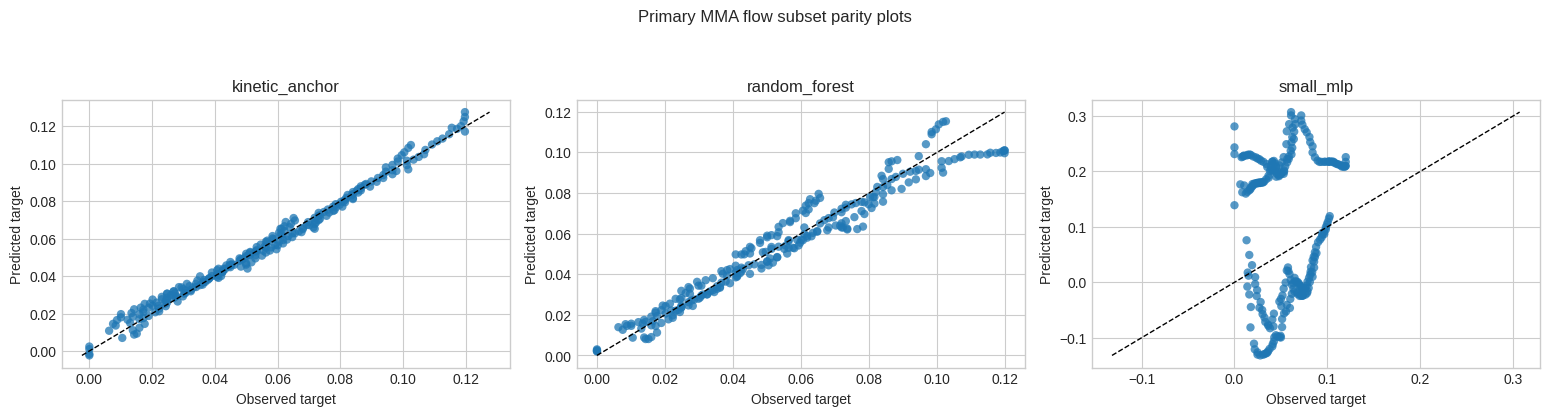

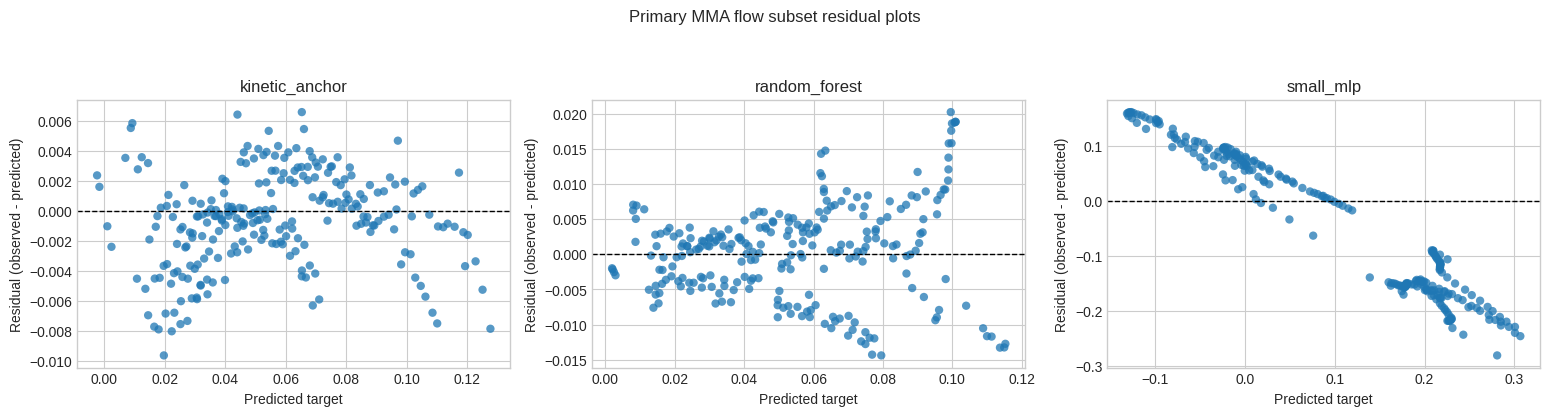

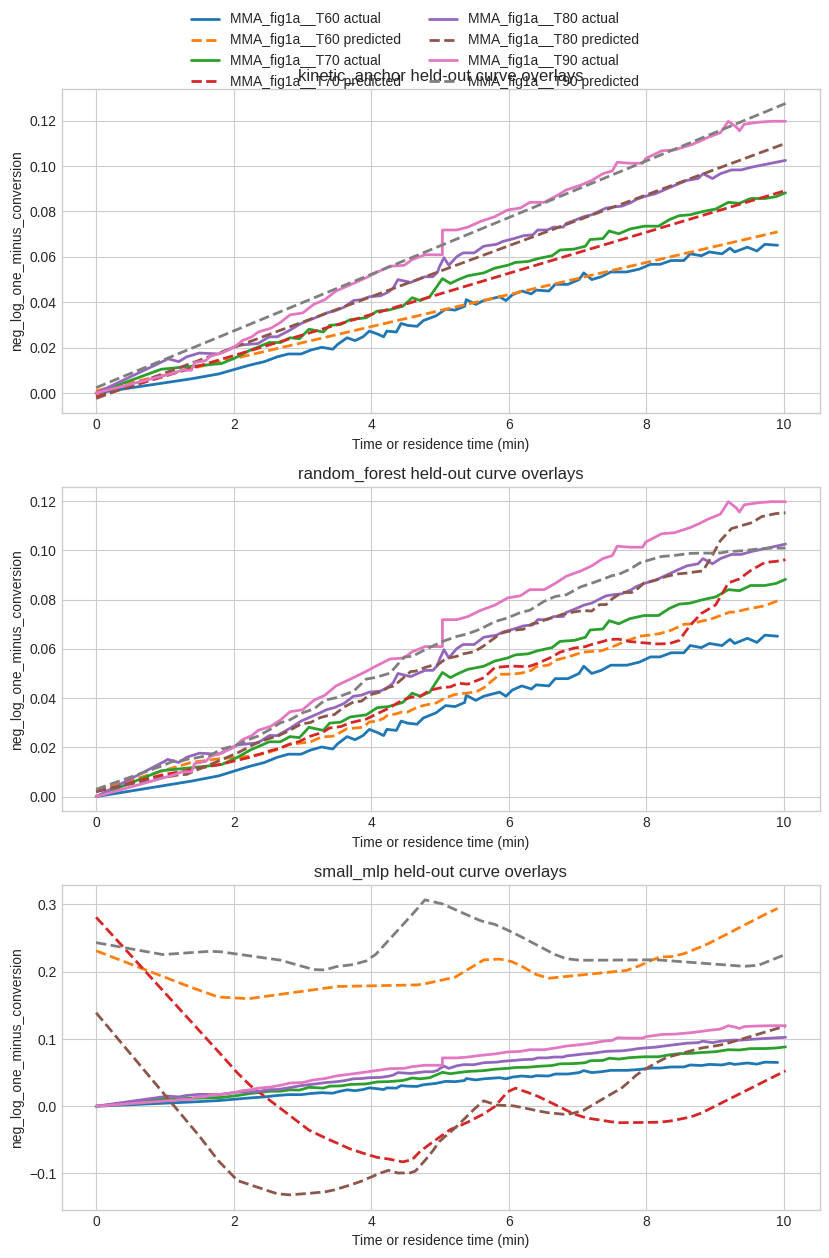


### How to read these baseline plots

- **Parity plots:** points close to the diagonal indicate accurate predictions. Systematic flattening or curvature means the model is missing part of the response structure.
- **Residual plots:** random scatter around zero is healthier than clear trends. A slope or funnel shape means bias or heteroskedastic error.
- **Held-out curve overlays:** the solid line is the observed curve and the dashed line is the prediction for the same held-out curve. These overlays matter more than training loss because the split is group-aware by `curve_id`.


In [17]:
primary_prediction_df = baseline_predictions_df.loc[baseline_predictions_df["subset_name"] == "primary_mma_flow_conversion"].copy()
if primary_prediction_df.empty:
    raise RuntimeError("Primary modeling subset did not produce any held-out predictions.")
model_names = primary_prediction_df["model_name"].dropna().unique().tolist()

parity_fig, parity_axes = plt.subplots(1, len(model_names), figsize=(5.2 * len(model_names), 4.2), squeeze=False)
for axis, model_name in zip(parity_axes.flatten(), model_names):
    model_df = primary_prediction_df.loc[primary_prediction_df["model_name"] == model_name].copy()
    axis.scatter(model_df["y_true"], model_df["y_pred"], alpha=0.75, edgecolor="none")
    low_bound = min(model_df["y_true"].min(), model_df["y_pred"].min())
    high_bound = max(model_df["y_true"].max(), model_df["y_pred"].max())
    axis.plot([low_bound, high_bound], [low_bound, high_bound], linestyle="--", color="black", linewidth=1.0)
    axis.set_title(model_name)
    axis.set_xlabel("Observed target")
    axis.set_ylabel("Predicted target")
parity_fig.suptitle("Primary MMA flow subset parity plots")
parity_fig.tight_layout(rect=[0, 0, 1, 0.92])
parity_path = save_figure(parity_fig, "primary_mma_flow_parity.png", display_inline=True)

residual_fig, residual_axes = plt.subplots(1, len(model_names), figsize=(5.2 * len(model_names), 4.2), squeeze=False)
for axis, model_name in zip(residual_axes.flatten(), model_names):
    model_df = primary_prediction_df.loc[primary_prediction_df["model_name"] == model_name].copy()
    axis.scatter(model_df["y_pred"], model_df["residual"], alpha=0.75, edgecolor="none")
    axis.axhline(0.0, linestyle="--", color="black", linewidth=1.0)
    axis.set_title(model_name)
    axis.set_xlabel("Predicted target")
    axis.set_ylabel("Residual (observed - predicted)")
residual_fig.suptitle("Primary MMA flow subset residual plots")
residual_fig.tight_layout(rect=[0, 0, 1, 0.92])
residual_path = save_figure(residual_fig, "primary_mma_flow_residuals.png", display_inline=True)

overlay_fig, overlay_axes = plt.subplots(len(model_names), 1, figsize=(8.4, 4.2 * len(model_names)), squeeze=False)
for axis, model_name in zip(overlay_axes.flatten(), model_names):
    model_df = primary_prediction_df.loc[primary_prediction_df["model_name"] == model_name].sort_values(["curve_id", "model_time_min"])
    for curve_id, curve_df in model_df.groupby("curve_id", dropna=False):
        axis.plot(curve_df["model_time_min"], curve_df["y_true"], linewidth=2.0, label=f"{curve_id} actual")
        axis.plot(curve_df["model_time_min"], curve_df["y_pred"], linestyle="--", linewidth=2.0, label=f"{curve_id} predicted")
    axis.set_title(f"{model_name} held-out curve overlays")
    axis.set_xlabel("Time or residence time (min)")
    axis.set_ylabel("neg_log_one_minus_conversion")
handles, labels = overlay_axes.flatten()[0].get_legend_handles_labels()
overlay_fig.legend(handles, labels, loc="upper center", ncol=2)
overlay_fig.tight_layout(rect=[0, 0, 1, 0.96])
overlay_path = save_figure(overlay_fig, "primary_mma_flow_curve_overlays.png", display_inline=True)


display(Markdown(textwrap.dedent("""
### How to read these baseline plots

- **Parity plots:** points close to the diagonal indicate accurate predictions. Systematic flattening or curvature means the model is missing part of the response structure.
- **Residual plots:** random scatter around zero is healthier than clear trends. A slope or funnel shape means bias or heteroskedastic error.
- **Held-out curve overlays:** the solid line is the observed curve and the dashed line is the prediction for the same held-out curve. These overlays matter more than training loss because the split is group-aware by `curve_id`.
""")))


## Section 15 - PCA Diagnostics Inside the Same Notebook

PCA is treated as a structural diagnostic only.


### Why PCA is included here

PCA is a structural diagnostic, not a mechanistic claim. It helps you see whether the different source families occupy obviously different parts of the simplified feature space. Strong separation is a warning against naïve pooling, not proof of causal chemistry.

,component,explained_variance_ratio
0,PC1,0.384739
1,PC2,0.190509


,curve_id,source_group,source_file,paper_id,regime_family,monomer,observations,measurement_types,temperature_C,time_min_min,time_min_max,residence_time_min_max,conversion_fraction_max,conversion_fraction_mean,neg_log_mean,Mn_mean,PDI_mean,PC1,PC2
0,MMA_fig1a__T60,MMA_fig1a,MMA_fig1a.xlsx,digitized_mma_sty_upload,raft_photo_flow_mma,MMA,61,conversion_kinetics,60.0,0.000000,9.907621,9.907621,0.063444,0.038284,0.039186,NaN,NaN,-2.533300,-0.277135
1,MMA_fig1a__T70,MMA_fig1a,MMA_fig1a.xlsx,digitized_mma_sty_upload,raft_photo_flow_mma,MMA,53,conversion_kinetics,70.0,0.000000,10.023095,10.023095,0.084455,0.050550,0.052148,NaN,NaN,-2.505020,-0.293845
2,MMA_fig1a__T80,MMA_fig1a,MMA_fig1a.xlsx,digitized_mma_sty_upload,raft_photo_flow_mma,MMA,71,conversion_kinetics,80.0,0.000000,10.023095,10.023095,0.097441,0.057987,0.060108,NaN,NaN,-2.973747,-0.394735
3,MMA_fig1a__T90,MMA_fig1a,MMA_fig1a.xlsx,digitized_mma_sty_upload,raft_photo_flow_mma,MMA,61,conversion_kinetics,90.0,0.000000,10.023095,10.023095,0.112856,0.065159,0.068081,NaN,NaN,-2.946553,-0.394470
4,MMA_fig2a__T45,MMA_fig2a,MMA_fig2a.xlsx,digitized_mma_sty_upload,raft_bulk_mma,MMA,5,conversion_kinetics,45.0,9.146341,270.121951,NaN,0.598075,0.315081,0.417191,NaN,NaN,1.520913,-0.011179


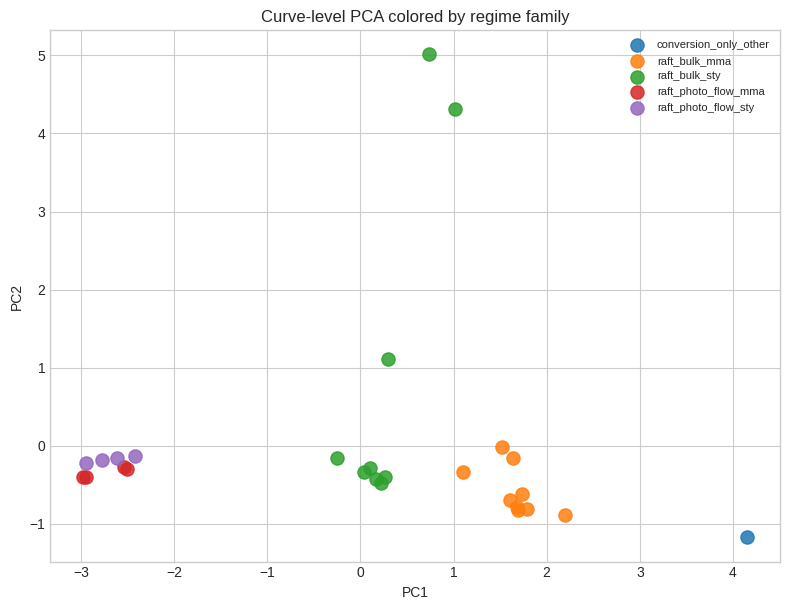

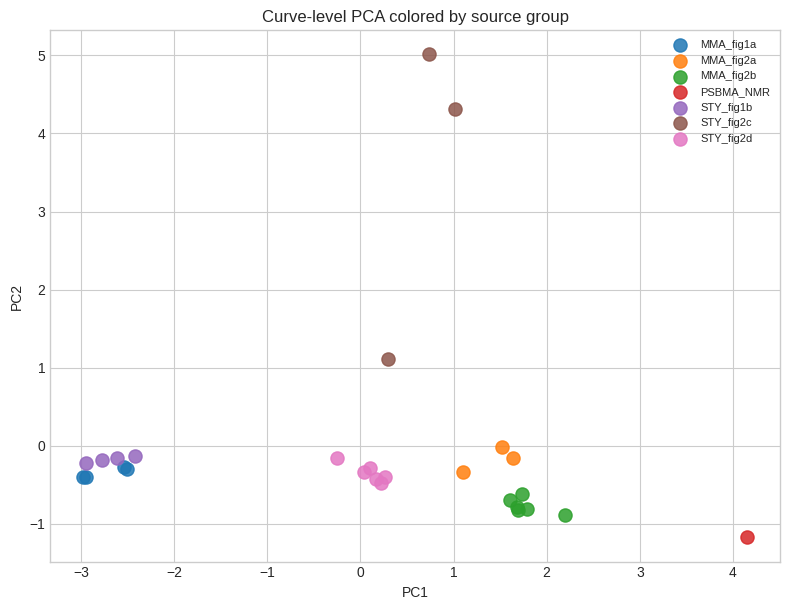


### How to read the PCA plots

- **PC1 and PC2** are compressed summary axes, not physical variables.
- Clear separation between colors suggests the curves differ structurally enough that blind pooling would be risky.
- Overlap does **not** prove the regimes are mechanistically identical; it only means the current numeric summary features do not fully separate them.


In [18]:
curve_feature_df = build_curve_feature_table(valid_rows_df)
pca_feature_columns = ["observations", "temperature_C", "time_min_min", "time_min_max", "residence_time_min_max", "conversion_fraction_max", "conversion_fraction_mean", "neg_log_mean", "Mn_mean", "PDI_mean"]
pca_input = SimpleImputer(strategy="median").fit_transform(curve_feature_df[pca_feature_columns])
pca_scaled = StandardScaler().fit_transform(pca_input)
pca_model = PCA(n_components=2)
pca_scores = pca_model.fit_transform(pca_scaled)
curve_pca_df = curve_feature_df.copy()
curve_pca_df["PC1"] = pca_scores[:, 0]
curve_pca_df["PC2"] = pca_scores[:, 1]
explained_variance_df = pd.DataFrame({"component": ["PC1", "PC2"], "explained_variance_ratio": pca_model.explained_variance_ratio_})
display(explained_variance_df)
display(curve_pca_df.head())

regime_fig, regime_axis = plt.subplots(figsize=(8.0, 6.2))
for regime_family, regime_df in curve_pca_df.groupby("regime_family", dropna=False):
    regime_axis.scatter(regime_df["PC1"], regime_df["PC2"], s=90, alpha=0.85, label=str(regime_family))
regime_axis.set_title("Curve-level PCA colored by regime family")
regime_axis.set_xlabel("PC1")
regime_axis.set_ylabel("PC2")
regime_axis.legend(loc="best", fontsize=8)
regime_fig.tight_layout()
pca_regime_path = save_figure(regime_fig, "curve_level_pca_by_regime.png", display_inline=True)

source_fig, source_axis = plt.subplots(figsize=(8.0, 6.2))
for source_group, source_df in curve_pca_df.groupby("source_group", dropna=False):
    source_axis.scatter(source_df["PC1"], source_df["PC2"], s=90, alpha=0.85, label=str(source_group))
source_axis.set_title("Curve-level PCA colored by source group")
source_axis.set_xlabel("PC1")
source_axis.set_ylabel("PC2")
source_axis.legend(loc="best", fontsize=8)
source_fig.tight_layout()
pca_source_path = save_figure(source_fig, "curve_level_pca_by_source.png", display_inline=True)


display(Markdown(textwrap.dedent("""
### How to read the PCA plots

- **PC1 and PC2** are compressed summary axes, not physical variables.
- Clear separation between colors suggests the curves differ structurally enough that blind pooling would be risky.
- Overlap does **not** prove the regimes are mechanistically identical; it only means the current numeric summary features do not fully separate them.
""")))


## Section 16 - Final Exports and Summary

The final step writes the required tabular artifacts, saves the figure set, and records a compact JSON summary.


### Why the export block matters

The notebook is not complete unless it leaves behind reusable artifacts. These exports make it possible to inspect the harmonized data, reuse the split assignments, compare future model runs against the current baseline, and debug the workflow without rerunning every earlier cell from memory.

In [19]:
harmonized_dataset_path = ARTIFACT_ROOT / "harmonized_dataset.csv"
qc_summary_path = ARTIFACT_ROOT / "qc_summary.csv"
split_assignments_path = ARTIFACT_ROOT / "split_assignments.csv"
subset_summary_path = ARTIFACT_ROOT / "subset_summary.csv"
baseline_metrics_path = ARTIFACT_ROOT / "baseline_metrics.csv"
baseline_predictions_path = ARTIFACT_ROOT / "baseline_predictions.csv"
mw_pairings_path = ARTIFACT_ROOT / "mn_pdi_pairings.csv"
curve_pca_path = ARTIFACT_ROOT / "curve_level_pca_scores.csv"
notebook_summary_path = ARTIFACT_ROOT / "notebook_summary.json"

harmonized_df.to_csv(harmonized_dataset_path, index=False)
qc_summary_df.to_csv(qc_summary_path, index=False)
split_assignments_df.to_csv(split_assignments_path, index=False)
subset_summary_df.to_csv(subset_summary_path, index=False)
baseline_metrics_export_df.to_csv(baseline_metrics_path, index=False)
baseline_predictions_df.to_csv(baseline_predictions_path, index=False)
approximate_mw_pairs_df.to_csv(mw_pairings_path, index=False)
curve_pca_df.to_csv(curve_pca_path, index=False)

notebook_summary = {
    "project_root": str(PROJECT_ROOT),
    "artifact_root": str(ARTIFACT_ROOT),
    "harmonized_rows": int(len(harmonized_df)),
    "harmonized_curves": int(harmonized_df["curve_id"].nunique()),
    "modeling_subsets": {subset_name: {"rows": int(len(analysis_subsets[subset_name])), "curves": int(analysis_subsets[subset_name]["curve_id"].nunique())} for subset_name in MODELING_SUBSET_NAMES},
    "validation_status_counts": harmonized_df["validation_status"].value_counts(dropna=False).to_dict(),
    "figure_paths": {"parity": str(parity_path), "residuals": str(residual_path), "curve_overlays": str(overlay_path), "pca_by_regime": str(pca_regime_path), "pca_by_source": str(pca_source_path)},
}
notebook_summary_path.write_text(json.dumps(notebook_summary, indent=2), encoding="utf-8")

written_files_df = pd.DataFrame([
    {"artifact": "harmonized_dataset", "path": str(harmonized_dataset_path)},
    {"artifact": "qc_summary", "path": str(qc_summary_path)},
    {"artifact": "split_assignments", "path": str(split_assignments_path)},
    {"artifact": "subset_summary", "path": str(subset_summary_path)},
    {"artifact": "baseline_metrics", "path": str(baseline_metrics_path)},
    {"artifact": "baseline_predictions", "path": str(baseline_predictions_path)},
    {"artifact": "mn_pdi_pairings", "path": str(mw_pairings_path)},
    {"artifact": "curve_level_pca_scores", "path": str(curve_pca_path)},
    {"artifact": "notebook_summary", "path": str(notebook_summary_path)},
])
display(written_files_df)
display(Markdown(textwrap.dedent(f"""
### End state

- The notebook now produces **{len(harmonized_df)} harmonized rows** across **{harmonized_df['curve_id'].nunique()} experimental curves**.
- The immediate modeling bridge is ready: grouped teacher-free baselines run on the narrow MMA and STY flow subsets without row-wise leakage.
- PCA is included inside this notebook as a structural diagnostic, not a mechanistic claim.
- The exported artifacts are ready for later mechanism-matched teacher work once that teacher actually exists.
""")))


,artifact,path
0,harmonized_dataset,/mnt/data/artifacts/polymer_new_data_end_to_end/harmonized_dataset.csv
1,qc_summary,/mnt/data/artifacts/polymer_new_data_end_to_end/qc_summary.csv
2,split_assignments,/mnt/data/artifacts/polymer_new_data_end_to_end/split_assignments.csv
3,subset_summary,/mnt/data/artifacts/polymer_new_data_end_to_end/subset_summary.csv
4,baseline_metrics,/mnt/data/artifacts/polymer_new_data_end_to_end/baseline_metrics.csv
5,baseline_predictions,/mnt/data/artifacts/polymer_new_data_end_to_end/baseline_predictions.csv
6,mn_pdi_pairings,/mnt/data/artifacts/polymer_new_data_end_to_end/mn_pdi_pairings.csv
7,curve_level_pca_scores,/mnt/data/artifacts/polymer_new_data_end_to_end/curve_level_pca_scores.csv
8,notebook_summary,/mnt/data/artifacts/polymer_new_data_end_to_end/notebook_summary.json



### End state

- The notebook now produces **585 harmonized rows** across **21 experimental curves**.
- The immediate modeling bridge is ready: grouped teacher-free baselines run on the narrow MMA and STY flow subsets without row-wise leakage.
- PCA is included inside this notebook as a structural diagnostic, not a mechanistic claim.
- The exported artifacts are ready for later mechanism-matched teacher work once that teacher actually exists.
